# Predicting Moral Values From Social Media Discourse

In [1]:
import os
import random
import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from itertools import product
from scipy.special import softmax
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    multilabel_confusion_matrix as mcm,
    precision_score,
    recall_score
)
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from tabulate import tabulate
from torch.autograd import Function
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset
from tqdm import trange
from tqdm.auto import trange
from transformers import (
    AutoConfig,
    AutoModel,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    BertModel,
    PretrainedConfig,
    PreTrainedModel,
    get_linear_schedule_with_warmup
)
from transformers.modeling_outputs import SequenceClassifierOutput

## Define Base Model

In [2]:
base_model = "bert-base-uncased"

### Datasets:
- These are the datasets retreived from different sources. Keep in mind that due to different cleaning, pre-processing, you might have different data sizes.

In [3]:
train_df = pd.read_csv("train_inggris.csv")
test_df = pd.read_csv("test_inggris.csv")
train_df.head()
test_df.head()

,storyID,judul,sentenceID,sentence,care,harm,fairness,cheating,loyalty,betrayal,authority,subversion,purity,degradation,liberty,oppression
0,1,The Fable of the Man Who Didn't Care for Story...,2,After a prolonged Experience he came to know t...,0,0,0,0,0,0,0,0,0,0,0,0
1,1,The Fable of the Man Who Didn't Care for Story...,7,That Settles it!,0,0,0,0,0,0,0,0,0,0,0,0
2,1,The Fable of the Man Who Didn't Care for Story...,8,3. The Book that runs into a Snarl of Dialect ...,0,0,0,0,0,0,0,0,0,0,0,0
3,1,The Fable of the Man Who Didn't Care for Story...,10,Jolly Story of the Slums.,0,0,0,0,0,0,0,0,0,0,0,0
4,1,The Fable of the Man Who Didn't Care for Story...,12,etc.,0,0,0,0,0,0,0,0,0,0,0,0


In [4]:
train_df.shape

(9962, 16)

In [5]:
train_df

,storyID,judul,sentenceID,sentence,care,harm,fairness,cheating,loyalty,betrayal,authority,subversion,purity,degradation,liberty,oppression
0,1,The Fable of the Man Who Didn't Care for Story...,1,"Once there was a blue Dyspeptic, who attempted...",0,1,0,0,0,0,0,0,0,0,0,0
1,1,The Fable of the Man Who Didn't Care for Story...,3,The Book that Promises well until you reach th...,0,0,0,0,0,0,0,0,0,0,0,0
2,1,The Fable of the Man Who Didn't Care for Story...,4,2. The book with the Author's Picture as a Fro...,0,0,0,0,0,0,0,0,0,0,0,0
3,1,The Fable of the Man Who Didn't Care for Story...,5,The Author is very Cocky.,0,0,0,0,0,0,0,0,0,0,0,0
4,1,The Fable of the Man Who Didn't Care for Story...,6,"He has his Overcoat thrown back, so as to reve...",0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9957,200,History of the Necronomicon,5,He is said by Ebn Khallikan (12th cent.,0,0,0,0,0,0,0,0,0,0,0,0
9958,200,History of the Necronomicon,6,biographer) to have been seized by an invisibl...,0,0,0,0,0,0,0,0,0,0,0,0
9959,200,History of the Necronomicon,7,Of his madness many things are told.,0,0,0,0,0,0,0,0,0,0,0,0
9960,200,History of the Necronomicon,8,"He claimed to have seen fabulous Irem, or City...",0,0,0,0,0,1,0,0,0,0,0,0


In [6]:
train_df[["care", "harm",
    "fairness", "cheating",
    "loyalty", "betrayal",
    "authority", "subversion",
    "purity", "degradation",
    "liberty", "oppression"]].sum()

,0
care,546
harm,430
fairness,282
cheating,75
loyalty,131
betrayal,37
authority,450
subversion,28
purity,81
degradation,34


In [7]:
neutral_text = train_df[(train_df['care']==0) & (train_df['harm']==0)
   & (train_df['fairness']==0) & (train_df['cheating']==0)
   & (train_df['loyalty']==0)  & (train_df['betrayal']==0)
   & (train_df['authority']==0)& (train_df['subversion']==0)
   & (train_df['purity']==0) & (train_df['degradation']==0)
   & (train_df['liberty']==0) & (train_df['oppression']==0)]

print("Neutral (Non-Moral) text: ", len(neutral_text))

Neutral (Non-Moral) text:  8011


In [8]:
len(neutral_text)/len(train_df)

0.8041557920096366

#### Text and label values:

In [9]:
possible_labels = [
    "care", "harm",
    "fairness", "cheating",
    "loyalty", "betrayal",
    "authority", "subversion",
    "purity", "degradation",
    "liberty", "oppression"
]

train_text = train_df["sentence"].values
train_labels = train_df[possible_labels].values

test_text = test_df["sentence"].values
test_labels = test_df[possible_labels].values

In [10]:
def encode_texts(input_texts, tokenizer, max_length=150):
    input_ids = []
    attention_masks = []
    token_type_ids = []

    for sample in input_texts:
        encoding = tokenizer(
            sample,
            add_special_tokens=True,
            max_length=max_length,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_token_type_ids=True,
            return_tensors="pt"
        )

        input_ids.append(encoding["input_ids"])
        attention_masks.append(encoding["attention_mask"])

        if "token_type_ids" in encoding:
            token_type_ids.append(encoding["token_type_ids"])
        else:
            token_type_ids.append(torch.zeros_like(encoding["input_ids"]))

    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)
    token_type_ids = torch.cat(token_type_ids, dim=0)

    return input_ids, attention_masks, token_type_ids

In [11]:
base_model = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(base_model)

train_input_ids, train_attention_masks, train_token_type_ids = encode_texts(
    train_text, tokenizer, max_length=150
)

test_input_ids, test_attention_masks, test_token_type_ids = encode_texts(
    test_text, tokenizer, max_length=150
)

train_labels_tensor = torch.tensor(train_labels, dtype=torch.float)
test_labels_tensor = torch.tensor(test_labels, dtype=torch.float)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

#### Encode corups for original embeddings

In [12]:
def encode_corpus(inputs, attentions, model, batch_size=16):

    all_embeddings = []

    model.eval()

    for start_index in range(0, len(inputs), batch_size):

        b_input_ids = inputs[start_index:start_index+batch_size].to(model.device)
        b_input_mask = attentions[start_index:start_index+batch_size].to(model.device)

        with torch.no_grad():

            outputs = model(
                input_ids=b_input_ids,
                attention_mask=b_input_mask
            )

            cls_embedding = outputs.last_hidden_state[:,0,:].cpu()

        all_embeddings.extend(cls_embedding)

    return torch.stack(all_embeddings)

### Doman Adversarial Function:

In [13]:
import os
import __main__

dummy_py_path = os.path.join(os.getcwd(), "notebook_session.py")
if not os.path.exists(dummy_py_path):
    with open(dummy_py_path, "w", encoding="utf-8") as f:
        f.write("# dummy file for transformers custom model in notebook\n")

__main__.__file__ = dummy_py_path

In [14]:
from transformers import PretrainedConfig, PreTrainedModel, AutoModel, AutoConfig
from transformers.modeling_outputs import SequenceClassifierOutput
import torch
import torch.nn as nn

class PlainBERTConfig(PretrainedConfig):
    model_type = "plainbert"

    def __init__(
        self,
        base_model_name_or_path="bert-base-uncased",
        num_labels=2,
        class_weight=None,
        identity_weight=0.0,
        reconstruction_weight=0.0,
        moral_weight=1.0,
        freeze_bert=False,
        id2label=None,
        label2id=None,
        **kwargs,
    ):
        super().__init__(num_labels=num_labels, id2label=id2label, label2id=label2id, **kwargs)
        self.base_model_name_or_path = base_model_name_or_path
        self.num_labels = num_labels
        self.class_weight = class_weight if class_weight is not None else [1.0] * num_labels
        self.identity_weight = float(identity_weight)
        self.reconstruction_weight = float(reconstruction_weight)
        self.moral_weight = float(moral_weight)
        self.freeze_bert = bool(freeze_bert)
        self.problem_type = "single_label_classification"


class PlainBERTForSequenceClassification(PreTrainedModel):
    config_class = PlainBERTConfig
    base_model_prefix = "bert"
    supports_gradient_checkpointing = False

    def __init__(self, config):
        super().__init__(config)

        self.num_labels = config.num_labels
        self.freeze = config.freeze_bert

        base_encoder_config = AutoConfig.from_pretrained(config.base_model_name_or_path)
        self.bert = AutoModel.from_pretrained(config.base_model_name_or_path)
        bert_dim = self.bert.config.hidden_size

        self.invariant_trans = nn.Linear(bert_dim, bert_dim)

        if config.identity_weight + config.reconstruction_weight == 0:
            self.moral_classification = nn.Linear(bert_dim, config.num_labels)
        else:
            self.moral_classification = nn.Sequential(
                nn.Linear(bert_dim, bert_dim),
                nn.ReLU(),
                nn.Linear(bert_dim, config.num_labels),
            )

        class_weight = config.class_weight if config.class_weight is not None else [1.0] * config.num_labels
        if class_weight and class_weight[0] > 0:
            weights = torch.tensor(class_weight).float()
        else:
            weights = torch.ones(config.num_labels).float()
        self.register_buffer("class_weights", weights)

        self.reconstruction_feed = nn.Linear(bert_dim, bert_dim)
        self.loss_reconstruction = nn.MSELoss()
        self.register_buffer("identity", torch.eye(bert_dim))

        try:
            self.post_init()
        except Exception as e:
            print("Warning during post_init:", e)

    def forward(
        self,
        input_ids=None,
        token_type_ids=None,
        attention_mask=None,
        labels=None,
        original_bert_embeddings=None,
        **kwargs,
    ):
        if self.freeze:
            with torch.no_grad():
                cls = self.bert(
                    input_ids=input_ids,
                    token_type_ids=token_type_ids,
                    attention_mask=attention_mask
                ).last_hidden_state[:, 0, :]
        else:
            cls = self.bert(
                input_ids=input_ids,
                token_type_ids=token_type_ids,
                attention_mask=attention_mask
            ).last_hidden_state[:, 0, :]

        z = self.invariant_trans(cls)
        logits = self.moral_classification(z)

        total_loss = None
        if labels is not None:
            loss_fn_moral = nn.CrossEntropyLoss(weight=self.class_weights)
            loss_moral = loss_fn_moral(logits, labels)

            if original_bert_embeddings is not None and self.config.reconstruction_weight > 0:
                loss_recon = self.loss_reconstruction(
                    self.reconstruction_feed(z),
                    original_bert_embeddings
                ) * self.config.reconstruction_weight
            else:
                loss_recon = 0.0

            if self.config.identity_weight > 0:
                loss_identity = torch.norm(
                    self.invariant_trans.weight - self.identity
                ) * self.config.identity_weight
            else:
                loss_identity = 0.0

            total_loss = (loss_moral * self.config.moral_weight) + loss_recon + loss_identity

        return SequenceClassifierOutput(loss=total_loss, logits=logits)

# Single Label Experiments

In [15]:
!pip install iterative-stratification

In [16]:
batch_size = 16

suffix = "_moral_multilabel_balinese"
print(suffix)

# Optional: mount Google Drive jika dijalankan di Google Colab
try:
    from google.colab import drive
    DRIVE_ROOT = "/content/drive"
    if not os.path.ismount(DRIVE_ROOT):
        drive.mount(DRIVE_ROOT)
except Exception:
    DRIVE_ROOT = None

HF_EXPORT_ROOT = Path("/content/drive/MyDrive/moralbert_inggris") if DRIVE_ROOT else Path("./moralbert_inggris")
HF_EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

PLAINBERT_CONFIGURATION_CODE = """
from transformers import PretrainedConfig

class PlainBERTConfig(PretrainedConfig):
    model_type = "plainbert"

    def __init__(
        self,
        base_model_name_or_path="bert-base-uncased",
        num_labels=2,
        class_weight=None,
        identity_weight=0.0,
        reconstruction_weight=0.0,
        moral_weight=1.0,
        freeze_bert=False,
        id2label=None,
        label2id=None,
        **kwargs,
    ):
        super().__init__(num_labels=num_labels, id2label=id2label, label2id=label2id, **kwargs)
        self.base_model_name_or_path = base_model_name_or_path
        self.num_labels = num_labels
        self.class_weight = class_weight if class_weight is not None else [1.0] * num_labels
        self.identity_weight = float(identity_weight)
        self.reconstruction_weight = float(reconstruction_weight)
        self.moral_weight = float(moral_weight)
        self.freeze_bert = bool(freeze_bert)
        self.problem_type = "single_label_classification"
"""

PLAINBERT_MODELING_CODE = """
import torch
import torch.nn as nn
from transformers import AutoModel, PreTrainedModel
from transformers.modeling_outputs import SequenceClassifierOutput
from configuration_plainbert import PlainBERTConfig

class PlainBERTForSequenceClassification(PreTrainedModel):
    config_class = PlainBERTConfig
    base_model_prefix = "bert"
    supports_gradient_checkpointing = False

    def __init__(self, config):
        super().__init__(config)

        self.num_labels = config.num_labels
        self.freeze = config.freeze_bert
        self.bert = AutoModel.from_pretrained(config.base_model_name_or_path)
        bert_dim = self.bert.config.hidden_size

        self.invariant_trans = nn.Linear(bert_dim, bert_dim)

        if config.identity_weight + config.reconstruction_weight == 0:
            self.moral_classification = nn.Linear(bert_dim, config.num_labels)
        else:
            self.moral_classification = nn.Sequential(
                nn.Linear(bert_dim, bert_dim),
                nn.ReLU(),
                nn.Linear(bert_dim, config.num_labels),
            )

        class_weight = config.class_weight if config.class_weight is not None else [1.0] * config.num_labels
        if class_weight and class_weight[0] > 0:
            weights = torch.tensor(class_weight).float()
        else:
            weights = torch.ones(config.num_labels).float()
        self.register_buffer("class_weights", weights)

        self.reconstruction_feed = nn.Linear(bert_dim, bert_dim)
        self.loss_reconstruction = nn.MSELoss()
        self.register_buffer("identity", torch.eye(bert_dim))
        self.post_init()

    def forward(
        self,
        input_ids=None,
        token_type_ids=None,
        attention_mask=None,
        labels=None,
        original_bert_embeddings=None,
        **kwargs,
    ):
        if self.freeze:
            with torch.no_grad():
                cls = self.bert(
                    input_ids=input_ids,
                    token_type_ids=token_type_ids,
                    attention_mask=attention_mask
                ).last_hidden_state[:, 0, :]
        else:
            cls = self.bert(
                input_ids=input_ids,
                token_type_ids=token_type_ids,
                attention_mask=attention_mask
            ).last_hidden_state[:, 0, :]

        z = self.invariant_trans(cls)
        logits = self.moral_classification(z)

        total_loss = None
        if labels is not None:
            loss_fn_moral = nn.CrossEntropyLoss(weight=self.class_weights)
            loss_moral = loss_fn_moral(logits, labels)

            if original_bert_embeddings is not None and self.config.reconstruction_weight > 0:
                loss_recon = self.loss_reconstruction(
                    self.reconstruction_feed(z),
                    original_bert_embeddings
                ) * self.config.reconstruction_weight
            else:
                loss_recon = 0.0

            if self.config.identity_weight > 0:
                loss_identity = torch.norm(
                    self.invariant_trans.weight - self.identity
                ) * self.config.identity_weight
            else:
                loss_identity = 0.0

            total_loss = (loss_moral * self.config.moral_weight) + loss_recon + loss_identity

        return SequenceClassifierOutput(loss=total_loss, logits=logits)
"""

def export_native_plainbert_checkpoint(model, tokenizer, export_root, label_name, best_f1, threshold=0.5):
    safe_label = label_name.replace(" ", "_")
    export_dir = Path(export_root) / safe_label
    export_dir.mkdir(parents=True, exist_ok=True)

    model.config.architectures = ["PlainBERTForSequenceClassification"]
    model.config.id2label = {"0": f"Non-{label_name}", "1": label_name}
    model.config.label2id = {f"Non-{label_name}": 0, label_name: 1}
    model.config.problem_type = "single_label_classification"
    model.config.best_validation_f1 = float(best_f1)
    model.config.recommended_threshold = float(threshold)
    model.config.auto_map = {
        "AutoConfig": "configuration_plainbert.PlainBERTConfig",
        "AutoModelForSequenceClassification": "modeling_plainbert.PlainBERTForSequenceClassification"
    }

    model.save_pretrained(export_dir)
    tokenizer.save_pretrained(export_dir)

    with open(export_dir / "configuration_plainbert.py", "w", encoding="utf-8") as f:
        f.write(PLAINBERT_CONFIGURATION_CODE)

    with open(export_dir / "modeling_plainbert.py", "w", encoding="utf-8") as f:
        f.write(PLAINBERT_MODELING_CODE)

    with open(export_dir / "README.md", "w", encoding="utf-8") as f:
        f.write(f"# PlainBERT native Hugging Face checkpoint for label: {label_name}\n\n")
        f.write(f"- Best validation F1: {best_f1:.4f}\n")
        f.write(f"- Recommended threshold: {threshold:.2f}\n\n")
        f.write("## Load from local folder or Hugging Face Hub\n")
        f.write("```python\n")
        f.write("from transformers import AutoTokenizer, AutoModelForSequenceClassification\n\n")
        f.write(f"repo_id_or_path = '{safe_label}'  # ganti dengan local path atau repo HF\n")
        f.write("tokenizer = AutoTokenizer.from_pretrained(repo_id_or_path, trust_remote_code=True)\n")
        f.write("model = AutoModelForSequenceClassification.from_pretrained(repo_id_or_path, trust_remote_code=True)\n")
        f.write("```\n")

    print(f"Saved best native HF checkpoint for '{label_name}' to: {export_dir}")

_moral_multilabel_balinese
Mounted at /content/drive


### Training:

/tmp/ipykernel_13171/1058689007.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Models for predicting moral dimension with BERT Base
Label: care
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Epochs for care:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.7409470752089137

Classification Report:
              precision    recall  f1-score   support

    Non-care       1.00      0.96      0.98      2355
        care       0.60      0.98      0.74       136

    accuracy                           0.96      2491
   macro avg       0.80      0.97      0.86      2491
weighted avg       0.98      0.96      0.97      2491


Train loss: 0.7456186480258097
Validation loss: 0.418584657403139


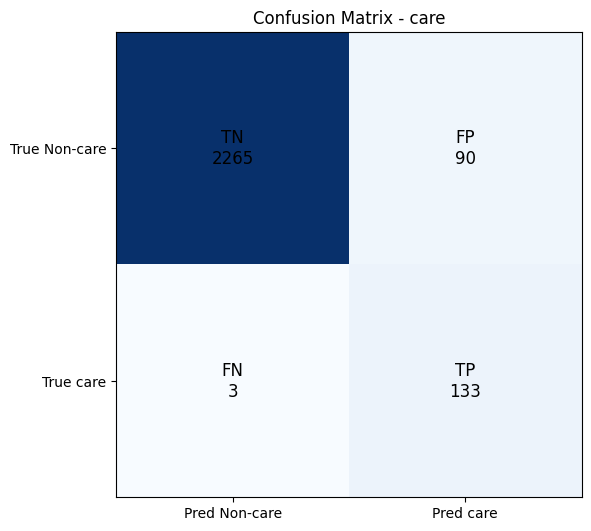

best_F1 0.7409470752089137
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'care' to: /content/drive/MyDrive/moralbert_inggris/care
Epoch: 2


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9370629370629371

Classification Report:
              precision    recall  f1-score   support

    Non-care       1.00      0.99      1.00      2355
        care       0.89      0.99      0.94       136

    accuracy                           0.99      2491
   macro avg       0.95      0.99      0.97      2491
weighted avg       0.99      0.99      0.99      2491


Train loss: 0.38030845754410636
Validation loss: 0.34848763851019054


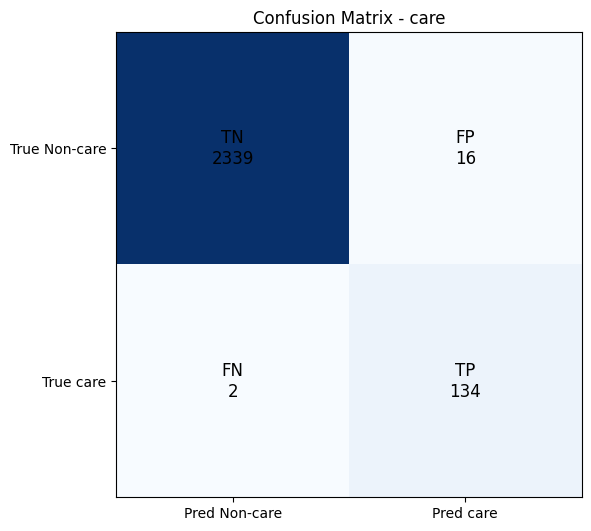

best_F1 0.9370629370629371
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'care' to: /content/drive/MyDrive/moralbert_inggris/care
Epoch: 3


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9642857142857143

Classification Report:
              precision    recall  f1-score   support

    Non-care       1.00      1.00      1.00      2355
        care       0.94      0.99      0.96       136

    accuracy                           1.00      2491
   macro avg       0.97      0.99      0.98      2491
weighted avg       1.00      1.00      1.00      2491


Train loss: 0.34215850293349304
Validation loss: 0.339373250802358


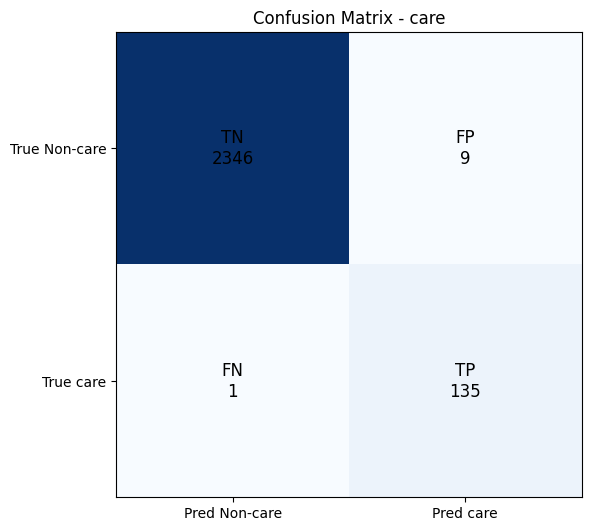

best_F1 0.9642857142857143
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'care' to: /content/drive/MyDrive/moralbert_inggris/care
Epoch: 4


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9507042253521126

Classification Report:
              precision    recall  f1-score   support

    Non-care       1.00      0.99      1.00      2355
        care       0.91      0.99      0.95       136

    accuracy                           0.99      2491
   macro avg       0.96      0.99      0.97      2491
weighted avg       0.99      0.99      0.99      2491


Train loss: 0.32807828741892575
Validation loss: 0.3405927576315709


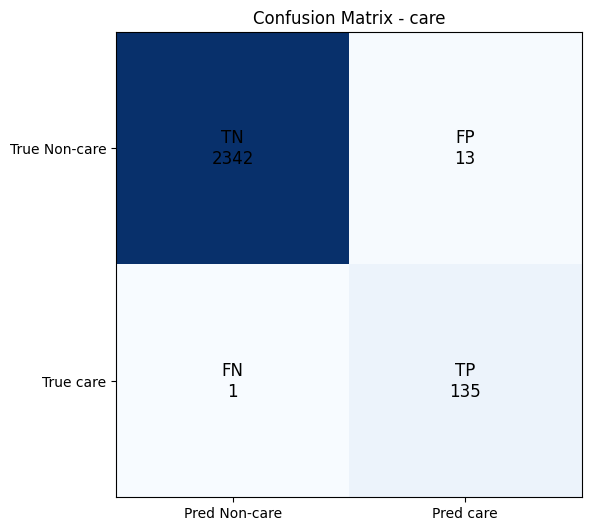

Epoch: 5


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9642857142857143

Classification Report:
              precision    recall  f1-score   support

    Non-care       1.00      1.00      1.00      2355
        care       0.94      0.99      0.96       136

    accuracy                           1.00      2491
   macro avg       0.97      0.99      0.98      2491
weighted avg       1.00      1.00      1.00      2491


Train loss: 0.32553996038092464
Validation loss: 0.340010234942803


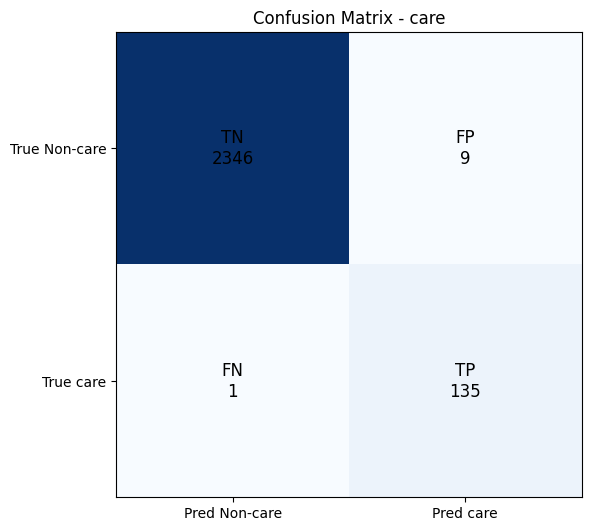

Models for predicting moral dimension with BERT Base
Label: harm
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for harm:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.6017191977077364

Classification Report:
              precision    recall  f1-score   support

    Non-harm       1.00      0.94      0.97      2383
        harm       0.44      0.97      0.60       108

    accuracy                           0.94      2491
   macro avg       0.72      0.96      0.79      2491
weighted avg       0.97      0.94      0.95      2491


Train loss: 0.7172238588524477
Validation loss: 0.44042792534216857


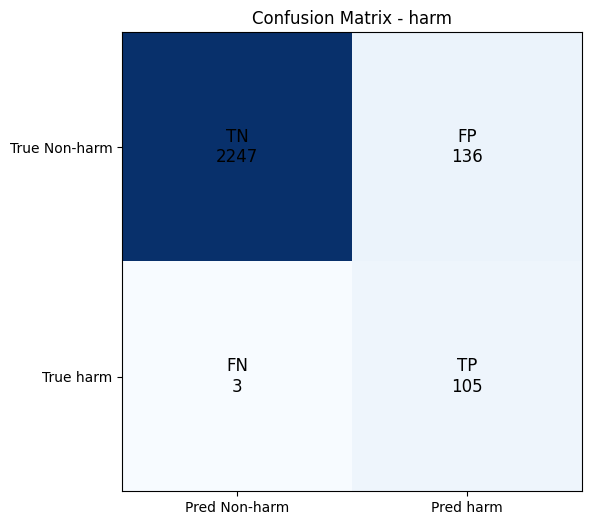

best_F1 0.6017191977077364
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'harm' to: /content/drive/MyDrive/moralbert_inggris/harm
Epoch: 2


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8408163265306122

Classification Report:
              precision    recall  f1-score   support

    Non-harm       1.00      0.99      0.99      2383
        harm       0.75      0.95      0.84       108

    accuracy                           0.98      2491
   macro avg       0.87      0.97      0.92      2491
weighted avg       0.99      0.98      0.99      2491


Train loss: 0.39182065037433444
Validation loss: 0.38658876506946027


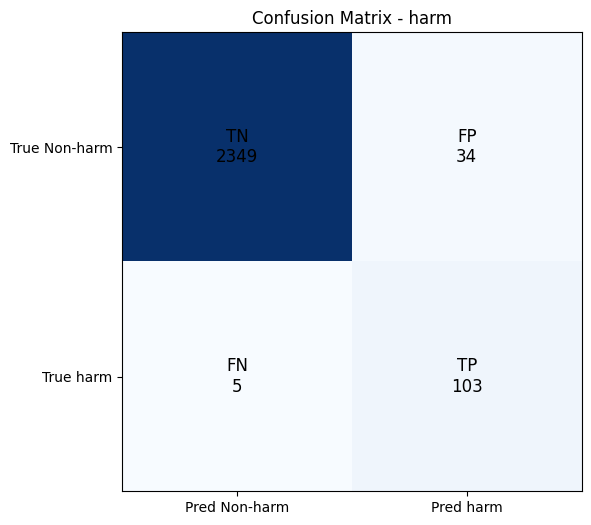

best_F1 0.8408163265306122
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'harm' to: /content/drive/MyDrive/moralbert_inggris/harm
Epoch: 3


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8927038626609443

Classification Report:
              precision    recall  f1-score   support

    Non-harm       1.00      0.99      0.99      2383
        harm       0.83      0.96      0.89       108

    accuracy                           0.99      2491
   macro avg       0.92      0.98      0.94      2491
weighted avg       0.99      0.99      0.99      2491


Train loss: 0.34382069814071226
Validation loss: 0.3980098605538026


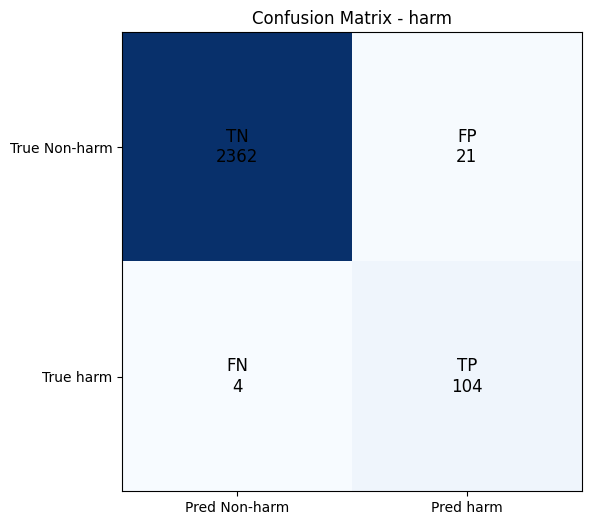

best_F1 0.8927038626609443
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'harm' to: /content/drive/MyDrive/moralbert_inggris/harm
Epoch: 4


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9279279279279279

Classification Report:
              precision    recall  f1-score   support

    Non-harm       1.00      1.00      1.00      2383
        harm       0.90      0.95      0.93       108

    accuracy                           0.99      2491
   macro avg       0.95      0.97      0.96      2491
weighted avg       0.99      0.99      0.99      2491


Train loss: 0.3329697927253778
Validation loss: 0.41060453481399095


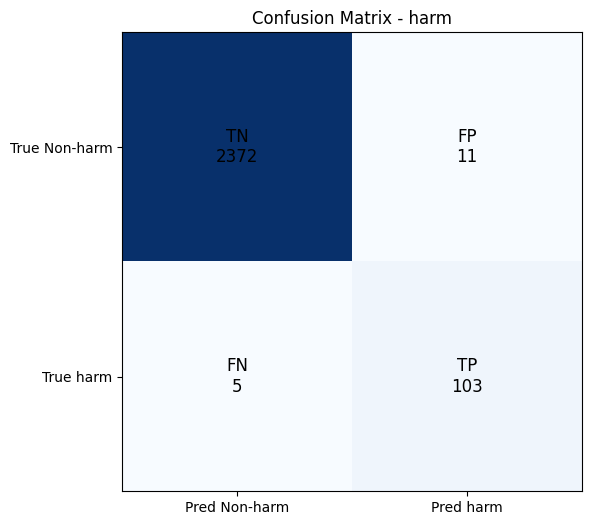

best_F1 0.9279279279279279
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'harm' to: /content/drive/MyDrive/moralbert_inggris/harm
Epoch: 5


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9237668161434978

Classification Report:
              precision    recall  f1-score   support

    Non-harm       1.00      0.99      1.00      2383
        harm       0.90      0.95      0.92       108

    accuracy                           0.99      2491
   macro avg       0.95      0.97      0.96      2491
weighted avg       0.99      0.99      0.99      2491


Train loss: 0.32658306529587
Validation loss: 0.4131289556240424


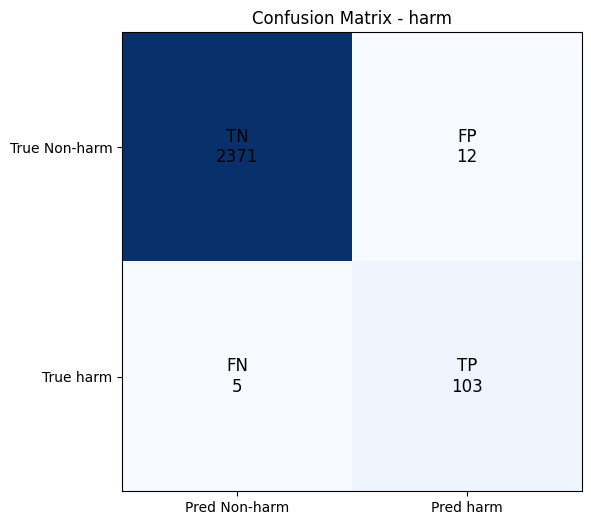

Models for predicting moral dimension with BERT Base
Label: fairness
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for fairness:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.5687203791469194

Classification Report:
              precision    recall  f1-score   support

Non-fairness       1.00      0.97      0.98      2421
    fairness       0.43      0.86      0.57        70

    accuracy                           0.96      2491
   macro avg       0.71      0.91      0.77      2491
weighted avg       0.98      0.96      0.97      2491


Train loss: 0.7884271861462111
Validation loss: 0.49790837997809434


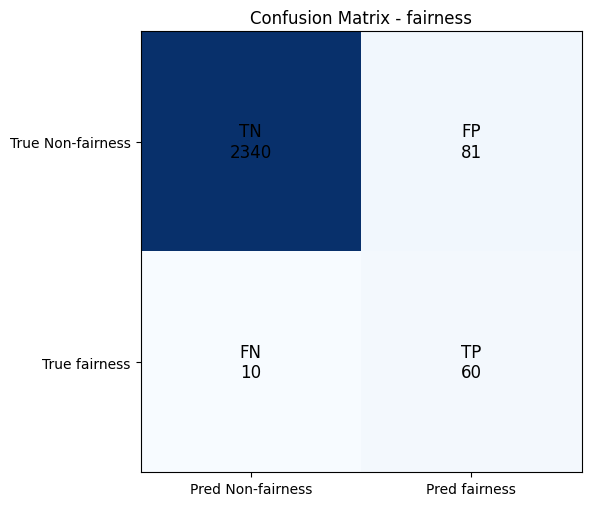

best_F1 0.5687203791469194
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'fairness' to: /content/drive/MyDrive/moralbert_inggris/fairness
Epoch: 2


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8920863309352518

Classification Report:
              precision    recall  f1-score   support

Non-fairness       1.00      1.00      1.00      2421
    fairness       0.90      0.89      0.89        70

    accuracy                           0.99      2491
   macro avg       0.95      0.94      0.94      2491
weighted avg       0.99      0.99      0.99      2491


Train loss: 0.42297554083084793
Validation loss: 0.4447414689721205


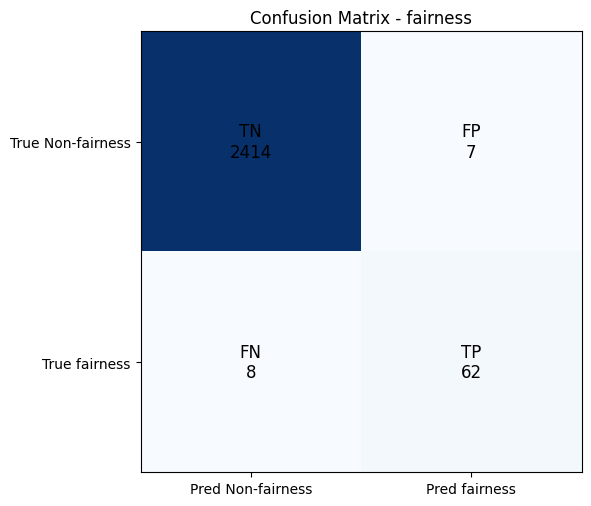

best_F1 0.8920863309352518
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'fairness' to: /content/drive/MyDrive/moralbert_inggris/fairness
Epoch: 3


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9014084507042254

Classification Report:
              precision    recall  f1-score   support

Non-fairness       1.00      1.00      1.00      2421
    fairness       0.89      0.91      0.90        70

    accuracy                           0.99      2491
   macro avg       0.94      0.96      0.95      2491
weighted avg       0.99      0.99      0.99      2491


Train loss: 0.35083912631099146
Validation loss: 0.42203117505862164


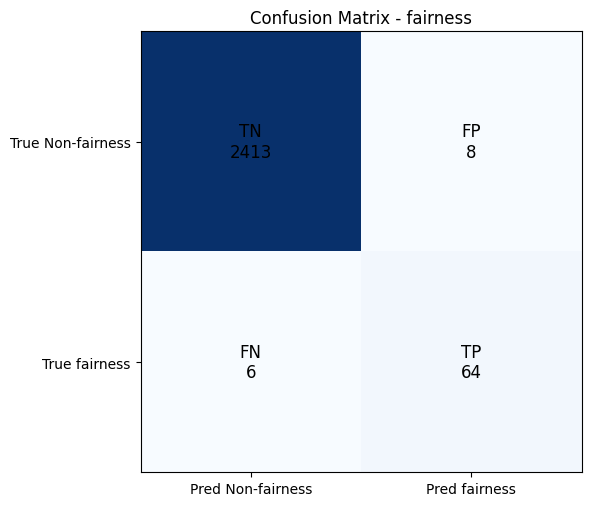

best_F1 0.9014084507042254
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'fairness' to: /content/drive/MyDrive/moralbert_inggris/fairness
Epoch: 4


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9402985074626866

Classification Report:
              precision    recall  f1-score   support

Non-fairness       1.00      1.00      1.00      2421
    fairness       0.98      0.90      0.94        70

    accuracy                           1.00      2491
   macro avg       0.99      0.95      0.97      2491
weighted avg       1.00      1.00      1.00      2491


Train loss: 0.33315623213161816
Validation loss: 0.4543908171546765


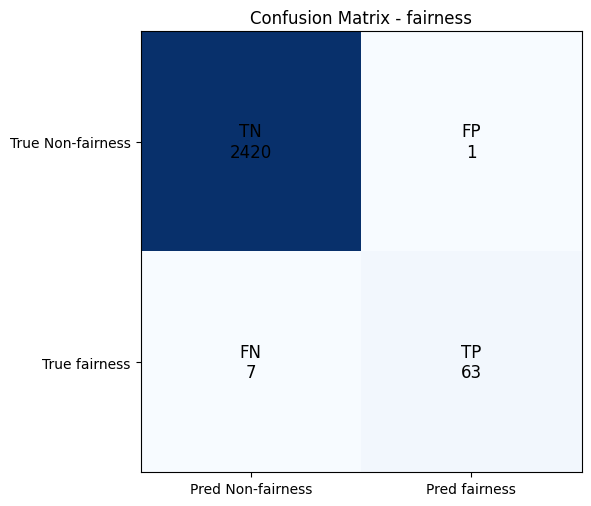

best_F1 0.9402985074626866
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'fairness' to: /content/drive/MyDrive/moralbert_inggris/fairness
Epoch: 5


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9402985074626866

Classification Report:
              precision    recall  f1-score   support

Non-fairness       1.00      1.00      1.00      2421
    fairness       0.98      0.90      0.94        70

    accuracy                           1.00      2491
   macro avg       0.99      0.95      0.97      2491
weighted avg       1.00      1.00      1.00      2491


Train loss: 0.32863459651198473
Validation loss: 0.4569314865347667


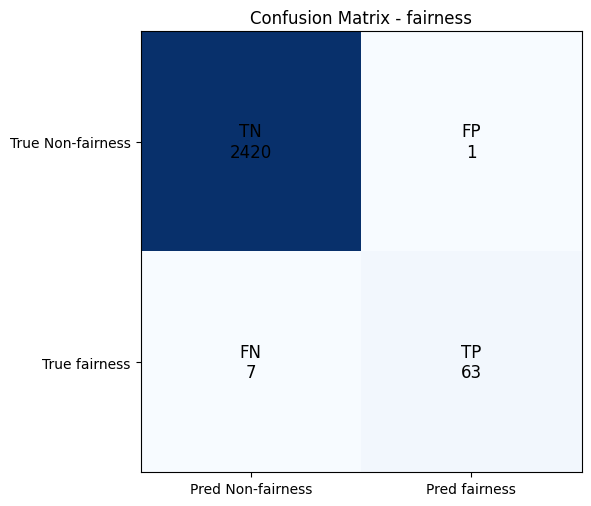

Models for predicting moral dimension with BERT Base
Label: cheating
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for cheating:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.3695652173913043

Classification Report:
              precision    recall  f1-score   support

Non-cheating       1.00      0.98      0.99      2472
    cheating       0.23      0.89      0.37        19

    accuracy                           0.98      2491
   macro avg       0.62      0.94      0.68      2491
weighted avg       0.99      0.98      0.98      2491


Train loss: 0.6326462251895121
Validation loss: 0.4267378013867598


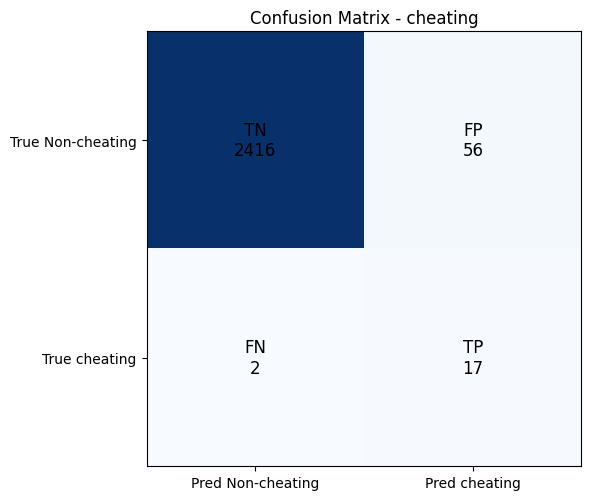

best_F1 0.3695652173913043
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'cheating' to: /content/drive/MyDrive/moralbert_inggris/cheating
Epoch: 2


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8421052631578947

Classification Report:
              precision    recall  f1-score   support

Non-cheating       1.00      1.00      1.00      2472
    cheating       0.84      0.84      0.84        19

    accuracy                           1.00      2491
   macro avg       0.92      0.92      0.92      2491
weighted avg       1.00      1.00      1.00      2491


Train loss: 0.38387369578569697
Validation loss: 0.39700567435759765


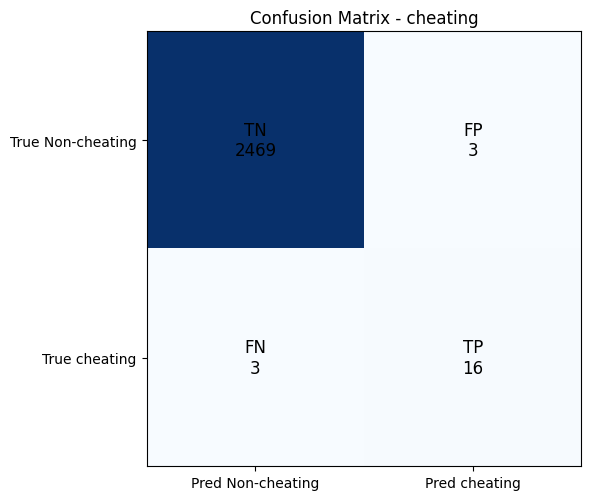

best_F1 0.8421052631578947
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'cheating' to: /content/drive/MyDrive/moralbert_inggris/cheating
Epoch: 3


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8333333333333334

Classification Report:
              precision    recall  f1-score   support

Non-cheating       1.00      1.00      1.00      2472
    cheating       0.88      0.79      0.83        19

    accuracy                           1.00      2491
   macro avg       0.94      0.89      0.92      2491
weighted avg       1.00      1.00      1.00      2491


Train loss: 0.33262997540386685
Validation loss: 0.4004888125719168


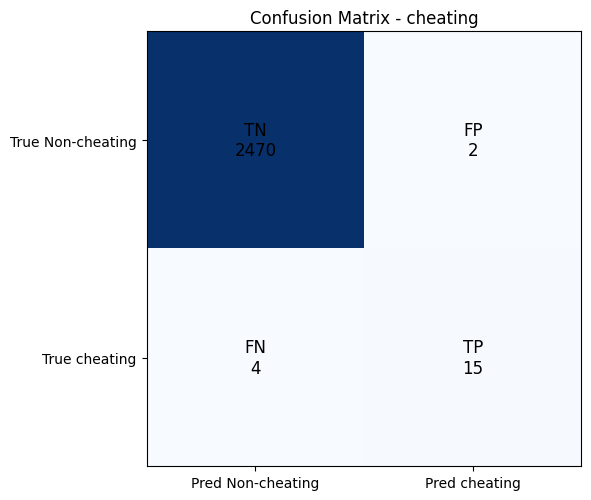

Epoch: 4


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8108108108108109

Classification Report:
              precision    recall  f1-score   support

Non-cheating       1.00      1.00      1.00      2472
    cheating       0.83      0.79      0.81        19

    accuracy                           1.00      2491
   macro avg       0.92      0.89      0.90      2491
weighted avg       1.00      1.00      1.00      2491


Train loss: 0.3240113015829273
Validation loss: 0.4051503013723936


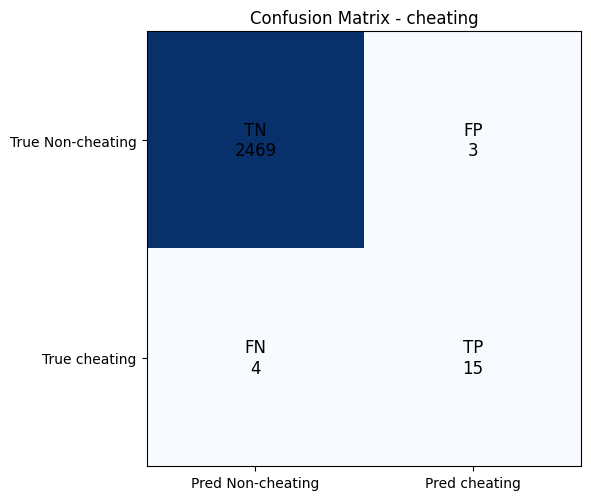

Epoch: 5


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.85

Classification Report:
              precision    recall  f1-score   support

Non-cheating       1.00      1.00      1.00      2472
    cheating       0.81      0.89      0.85        19

    accuracy                           1.00      2491
   macro avg       0.90      0.95      0.92      2491
weighted avg       1.00      1.00      1.00      2491


Train loss: 0.32326421950066264
Validation loss: 0.3920722458607111


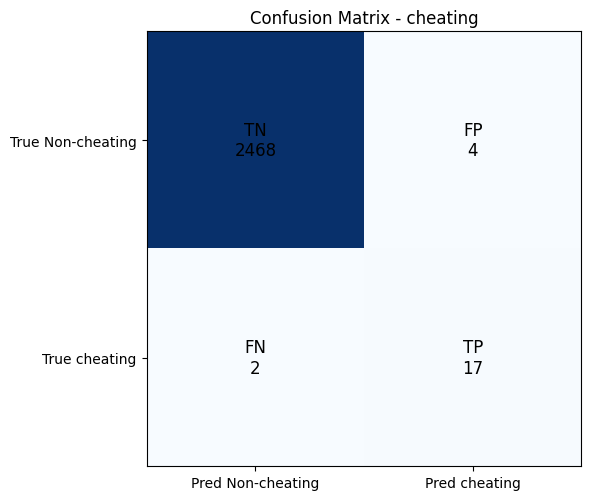

best_F1 0.85
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'cheating' to: /content/drive/MyDrive/moralbert_inggris/cheating
Models for predicting moral dimension with BERT Base
Label: loyalty
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Epochs for loyalty:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.5531914893617021

Classification Report:
              precision    recall  f1-score   support

 Non-loyalty       0.99      1.00      1.00      2458
     loyalty       0.93      0.39      0.55        33

    accuracy                           0.99      2491
   macro avg       0.96      0.70      0.77      2491
weighted avg       0.99      0.99      0.99      2491


Train loss: 0.714416117384958
Validation loss: 0.6083299131729664


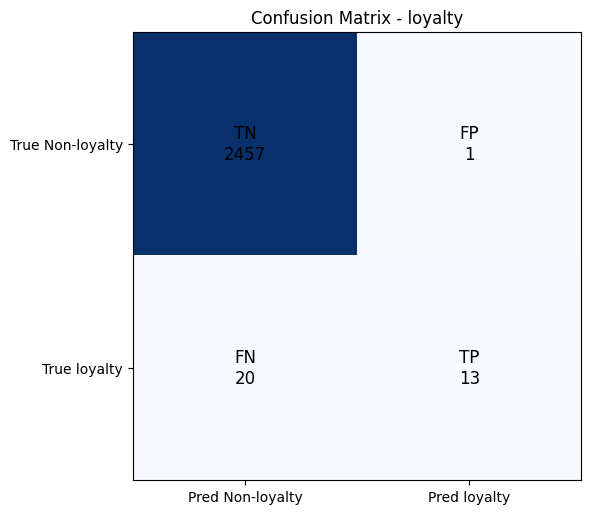

best_F1 0.5531914893617021
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'loyalty' to: /content/drive/MyDrive/moralbert_inggris/loyalty
Epoch: 2


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.6376811594202898

Classification Report:
              precision    recall  f1-score   support

 Non-loyalty       1.00      0.99      0.99      2458
     loyalty       0.61      0.67      0.64        33

    accuracy                           0.99      2491
   macro avg       0.80      0.83      0.82      2491
weighted avg       0.99      0.99      0.99      2491


Train loss: 0.5217097046191581
Validation loss: 0.5063393511451207


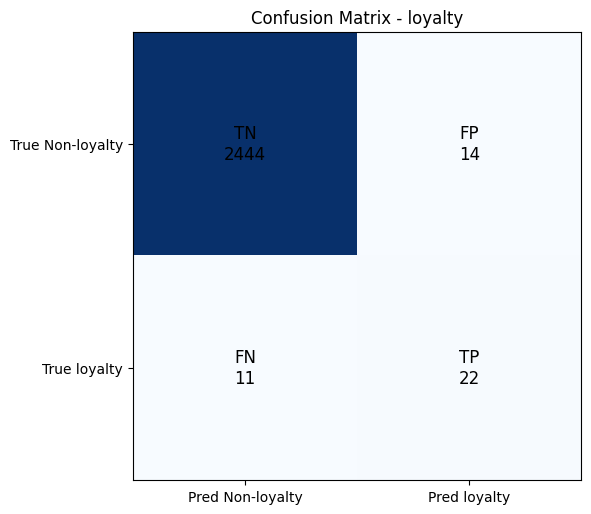

best_F1 0.6376811594202898
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'loyalty' to: /content/drive/MyDrive/moralbert_inggris/loyalty
Epoch: 3


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.7164179104477612

Classification Report:
              precision    recall  f1-score   support

 Non-loyalty       1.00      1.00      1.00      2458
     loyalty       0.71      0.73      0.72        33

    accuracy                           0.99      2491
   macro avg       0.85      0.86      0.86      2491
weighted avg       0.99      0.99      0.99      2491


Train loss: 0.37179049806457076
Validation loss: 0.4912273725255942


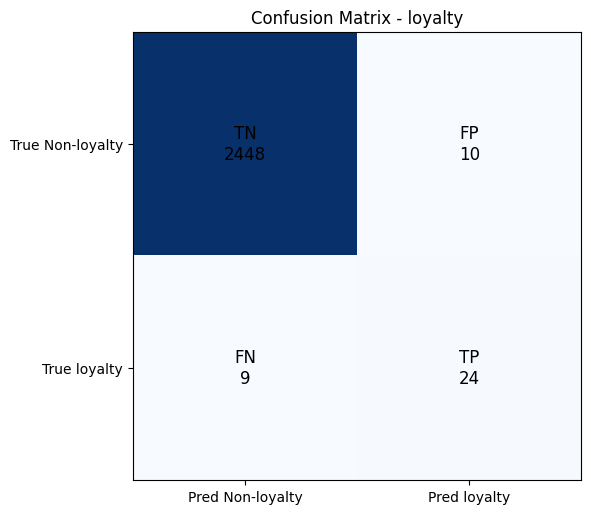

best_F1 0.7164179104477612
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'loyalty' to: /content/drive/MyDrive/moralbert_inggris/loyalty
Epoch: 4


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.7636363636363637

Classification Report:
              precision    recall  f1-score   support

 Non-loyalty       1.00      1.00      1.00      2458
     loyalty       0.95      0.64      0.76        33

    accuracy                           0.99      2491
   macro avg       0.97      0.82      0.88      2491
weighted avg       0.99      0.99      0.99      2491


Train loss: 0.3348455721359957
Validation loss: 0.561445608161963


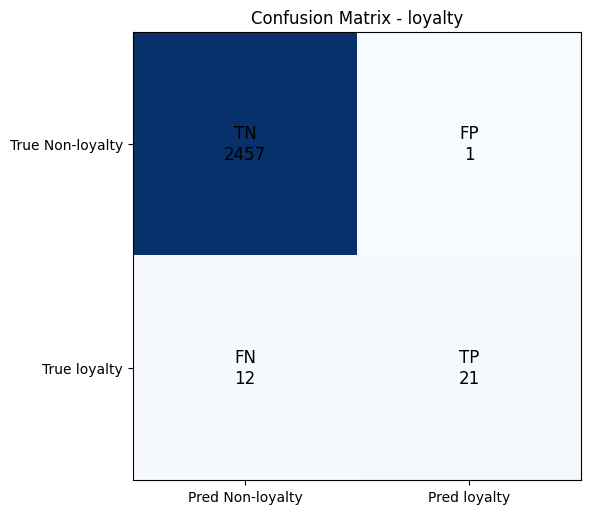

best_F1 0.7636363636363637
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'loyalty' to: /content/drive/MyDrive/moralbert_inggris/loyalty
Epoch: 5


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.7457627118644068

Classification Report:
              precision    recall  f1-score   support

 Non-loyalty       1.00      1.00      1.00      2458
     loyalty       0.85      0.67      0.75        33

    accuracy                           0.99      2491
   macro avg       0.92      0.83      0.87      2491
weighted avg       0.99      0.99      0.99      2491


Train loss: 0.33227428152894134
Validation loss: 0.5475380808497087


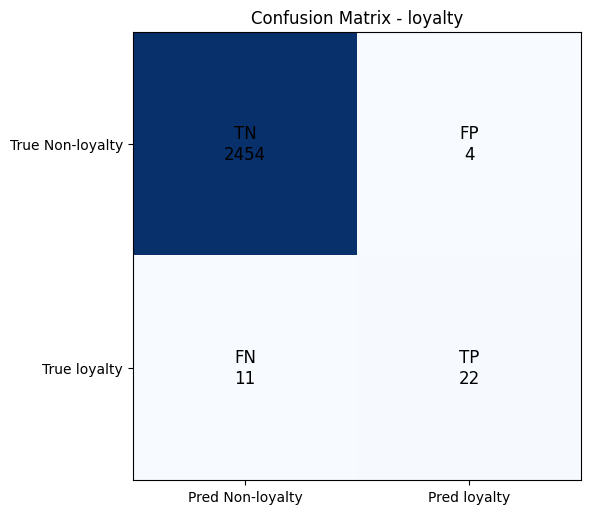

Models for predicting moral dimension with BERT Base
Label: betrayal
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for betrayal:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.0

Classification Report:
              precision    recall  f1-score   support

Non-betrayal       1.00      1.00      1.00      2482
    betrayal       0.00      0.00      0.00         9

    accuracy                           1.00      2491
   macro avg       0.50      0.50      0.50      2491
weighted avg       0.99      1.00      0.99      2491


Train loss: 0.5593001145995065
Validation loss: 0.4873940954223657


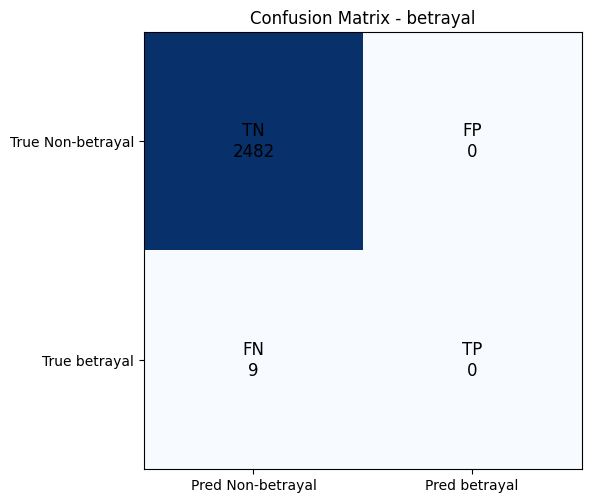

best_F1 0.0
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'betrayal' to: /content/drive/MyDrive/moralbert_inggris/betrayal
Epoch: 2


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.4

Classification Report:
              precision    recall  f1-score   support

Non-betrayal       1.00      1.00      1.00      2482
    betrayal       0.36      0.44      0.40         9

    accuracy                           1.00      2491
   macro avg       0.68      0.72      0.70      2491
weighted avg       1.00      1.00      1.00      2491


Train loss: 0.4594733289788278
Validation loss: 0.41072798749575246


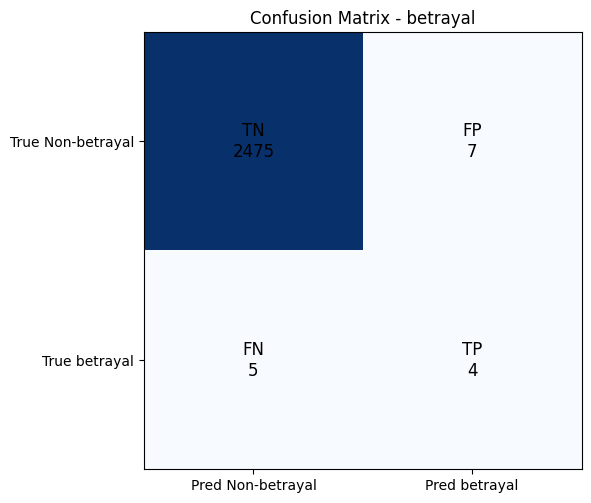

best_F1 0.4
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'betrayal' to: /content/drive/MyDrive/moralbert_inggris/betrayal
Epoch: 3


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.7777777777777778

Classification Report:
              precision    recall  f1-score   support

Non-betrayal       1.00      1.00      1.00      2482
    betrayal       0.78      0.78      0.78         9

    accuracy                           1.00      2491
   macro avg       0.89      0.89      0.89      2491
weighted avg       1.00      1.00      1.00      2491


Train loss: 0.3431090690542377
Validation loss: 0.3797512480463737


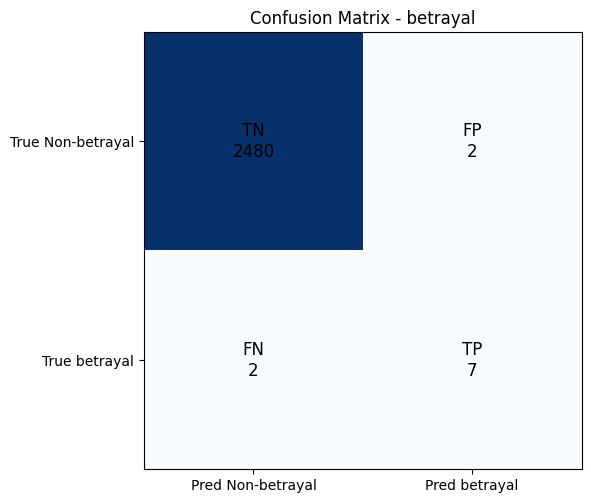

best_F1 0.7777777777777778
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'betrayal' to: /content/drive/MyDrive/moralbert_inggris/betrayal
Epoch: 4


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8235294117647058

Classification Report:
              precision    recall  f1-score   support

Non-betrayal       1.00      1.00      1.00      2482
    betrayal       0.88      0.78      0.82         9

    accuracy                           1.00      2491
   macro avg       0.94      0.89      0.91      2491
weighted avg       1.00      1.00      1.00      2491


Train loss: 0.32742490321636963
Validation loss: 0.3651540564038815


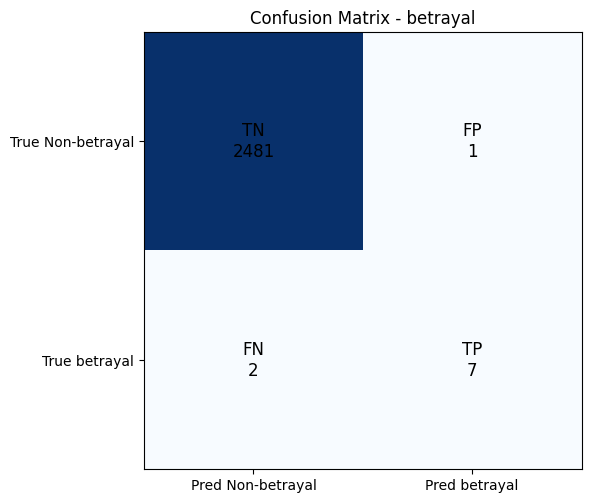

best_F1 0.8235294117647058
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'betrayal' to: /content/drive/MyDrive/moralbert_inggris/betrayal
Epoch: 5


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8235294117647058

Classification Report:
              precision    recall  f1-score   support

Non-betrayal       1.00      1.00      1.00      2482
    betrayal       0.88      0.78      0.82         9

    accuracy                           1.00      2491
   macro avg       0.94      0.89      0.91      2491
weighted avg       1.00      1.00      1.00      2491


Train loss: 0.32458872554964274
Validation loss: 0.3662630441861275


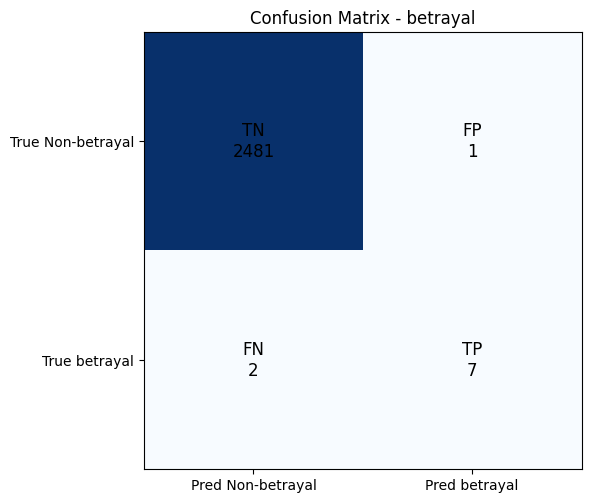

Models for predicting moral dimension with BERT Base
Label: authority
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for authority:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8333333333333334

Classification Report:
               precision    recall  f1-score   support

Non-authority       0.99      0.99      0.99      2379
    authority       0.78      0.89      0.83       112

     accuracy                           0.98      2491
    macro avg       0.89      0.94      0.91      2491
 weighted avg       0.99      0.98      0.98      2491


Train loss: 0.7365972008885006
Validation loss: 0.44757675379514694


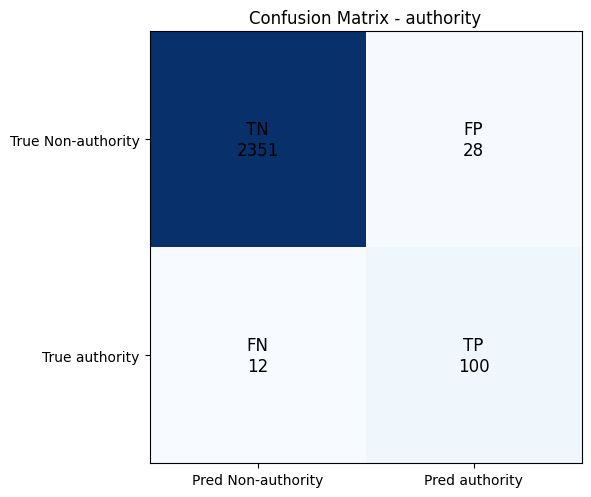

best_F1 0.8333333333333334
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'authority' to: /content/drive/MyDrive/moralbert_inggris/authority
Epoch: 2


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9732142857142857

Classification Report:
               precision    recall  f1-score   support

Non-authority       1.00      1.00      1.00      2379
    authority       0.97      0.97      0.97       112

     accuracy                           1.00      2491
    macro avg       0.99      0.99      0.99      2491
 weighted avg       1.00      1.00      1.00      2491


Train loss: 0.40183357308419904
Validation loss: 0.3622786183005724


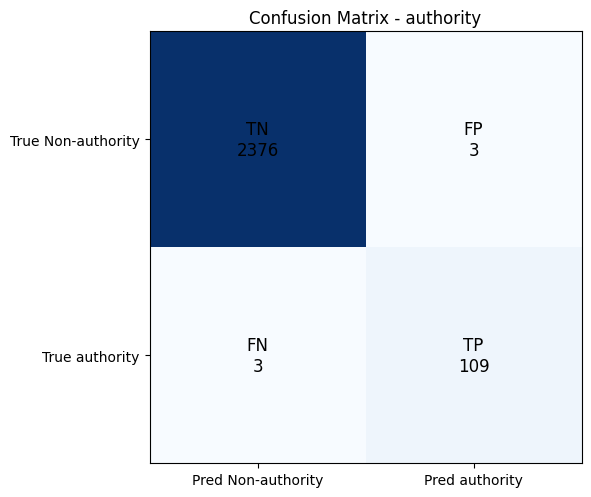

best_F1 0.9732142857142857
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'authority' to: /content/drive/MyDrive/moralbert_inggris/authority
Epoch: 3


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.940677966101695

Classification Report:
               precision    recall  f1-score   support

Non-authority       1.00      0.99      1.00      2379
    authority       0.90      0.99      0.94       112

     accuracy                           0.99      2491
    macro avg       0.95      0.99      0.97      2491
 weighted avg       0.99      0.99      0.99      2491


Train loss: 0.34397500806023185
Validation loss: 0.3304864491025607


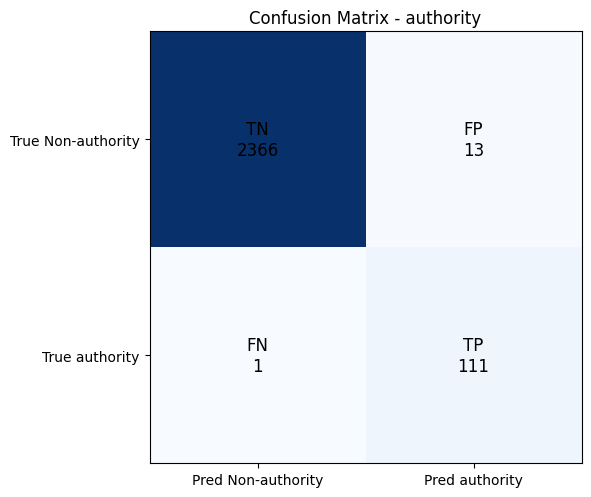

Epoch: 4


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9823008849557522

Classification Report:
               precision    recall  f1-score   support

Non-authority       1.00      1.00      1.00      2379
    authority       0.97      0.99      0.98       112

     accuracy                           1.00      2491
    macro avg       0.99      0.99      0.99      2491
 weighted avg       1.00      1.00      1.00      2491


Train loss: 0.33481734206550195
Validation loss: 0.32553636932220215


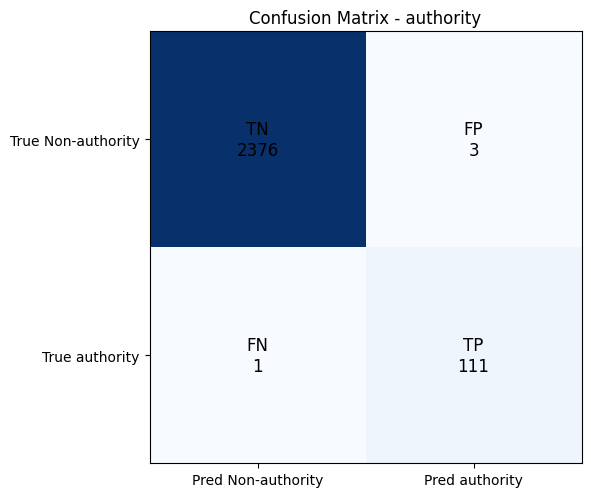

best_F1 0.9823008849557522
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'authority' to: /content/drive/MyDrive/moralbert_inggris/authority
Epoch: 5


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9823008849557522

Classification Report:
               precision    recall  f1-score   support

Non-authority       1.00      1.00      1.00      2379
    authority       0.97      0.99      0.98       112

     accuracy                           1.00      2491
    macro avg       0.99      0.99      0.99      2491
 weighted avg       1.00      1.00      1.00      2491


Train loss: 0.32809837719793306
Validation loss: 0.32592603736198866


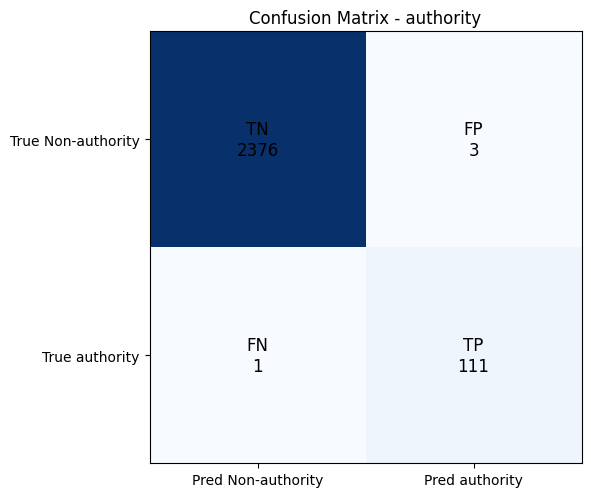

Models for predicting moral dimension with BERT Base
Label: subversion
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for subversion:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.0

Classification Report:
                precision    recall  f1-score   support

Non-subversion       1.00      1.00      1.00      2484
    subversion       0.00      0.00      0.00         7

      accuracy                           1.00      2491
     macro avg       0.50      0.50      0.50      2491
  weighted avg       0.99      1.00      1.00      2491


Train loss: 0.5220591689954791
Validation loss: 0.4459735837120276


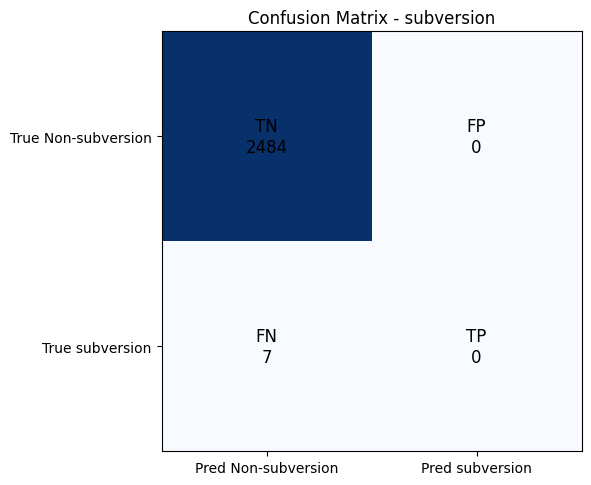

best_F1 0.0
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'subversion' to: /content/drive/MyDrive/moralbert_inggris/subversion
Epoch: 2


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.5

Classification Report:
                precision    recall  f1-score   support

Non-subversion       1.00      1.00      1.00      2484
    subversion       0.60      0.43      0.50         7

      accuracy                           1.00      2491
     macro avg       0.80      0.71      0.75      2491
  weighted avg       1.00      1.00      1.00      2491


Train loss: 0.40934852913715675
Validation loss: 0.38143601077489364


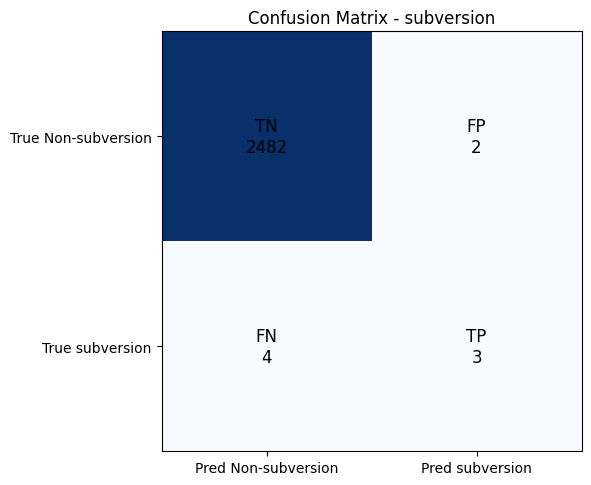

best_F1 0.5
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'subversion' to: /content/drive/MyDrive/moralbert_inggris/subversion
Epoch: 3


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.7272727272727273

Classification Report:
                precision    recall  f1-score   support

Non-subversion       1.00      1.00      1.00      2484
    subversion       1.00      0.57      0.73         7

      accuracy                           1.00      2491
     macro avg       1.00      0.79      0.86      2491
  weighted avg       1.00      1.00      1.00      2491


Train loss: 0.33106056539817186
Validation loss: 0.3941651448989526


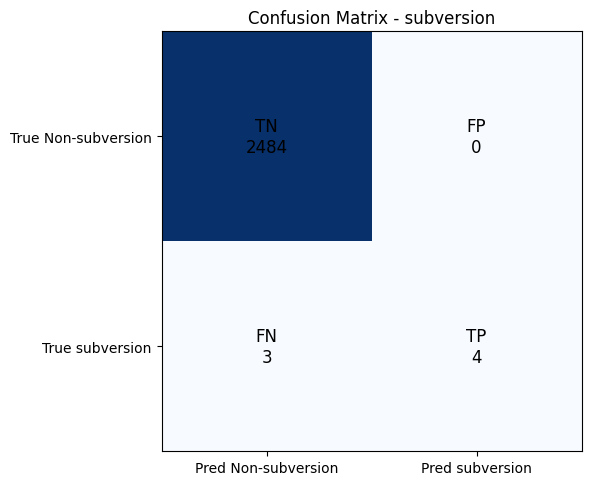

best_F1 0.7272727272727273
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'subversion' to: /content/drive/MyDrive/moralbert_inggris/subversion
Epoch: 4


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.7272727272727273

Classification Report:
                precision    recall  f1-score   support

Non-subversion       1.00      1.00      1.00      2484
    subversion       1.00      0.57      0.73         7

      accuracy                           1.00      2491
     macro avg       1.00      0.79      0.86      2491
  weighted avg       1.00      1.00      1.00      2491


Train loss: 0.32412011885528197
Validation loss: 0.4046339883636206


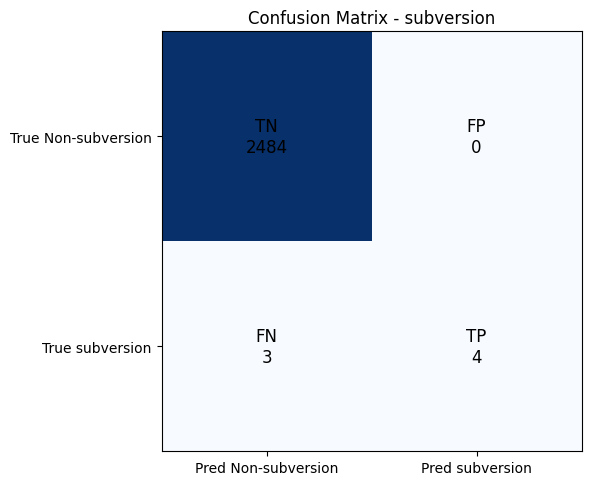

Epoch: 5


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.7272727272727273

Classification Report:
                precision    recall  f1-score   support

Non-subversion       1.00      1.00      1.00      2484
    subversion       1.00      0.57      0.73         7

      accuracy                           1.00      2491
     macro avg       1.00      0.79      0.86      2491
  weighted avg       1.00      1.00      1.00      2491


Train loss: 0.32282751167184087
Validation loss: 0.40971979116782165


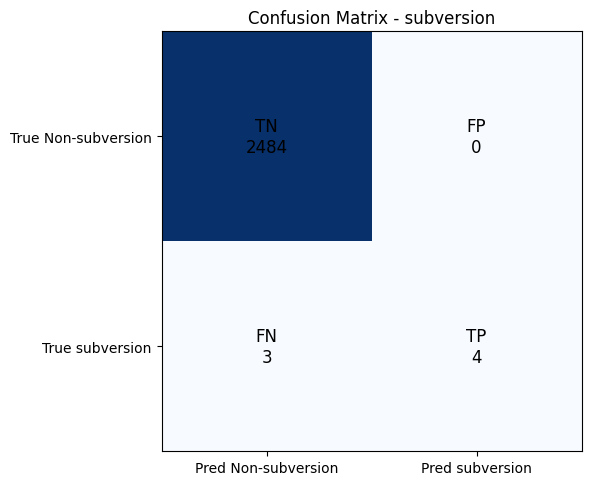

Models for predicting moral dimension with BERT Base
Label: purity
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for purity:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.2608695652173913

Classification Report:
              precision    recall  f1-score   support

  Non-purity       0.99      1.00      1.00      2471
      purity       1.00      0.15      0.26        20

    accuracy                           0.99      2491
   macro avg       1.00      0.57      0.63      2491
weighted avg       0.99      0.99      0.99      2491


Train loss: 0.6692079107126111
Validation loss: 0.5739734841462893


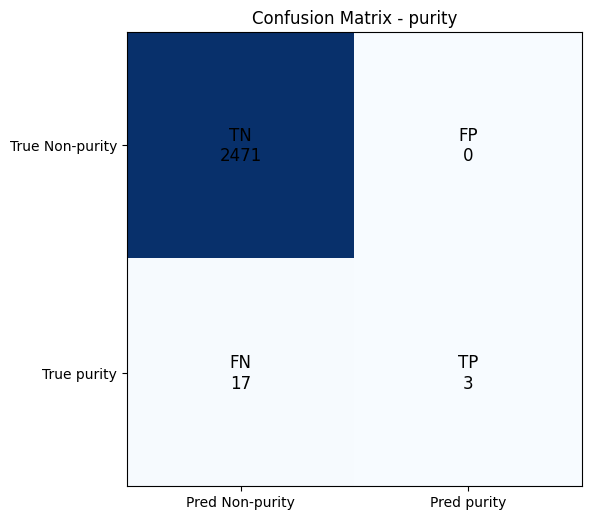

best_F1 0.2608695652173913
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'purity' to: /content/drive/MyDrive/moralbert_inggris/purity
Epoch: 2


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.7692307692307693

Classification Report:
              precision    recall  f1-score   support

  Non-purity       1.00      1.00      1.00      2471
      purity       0.79      0.75      0.77        20

    accuracy                           1.00      2491
   macro avg       0.89      0.87      0.88      2491
weighted avg       1.00      1.00      1.00      2491


Train loss: 0.4754863953513854
Validation loss: 0.4295525304400004


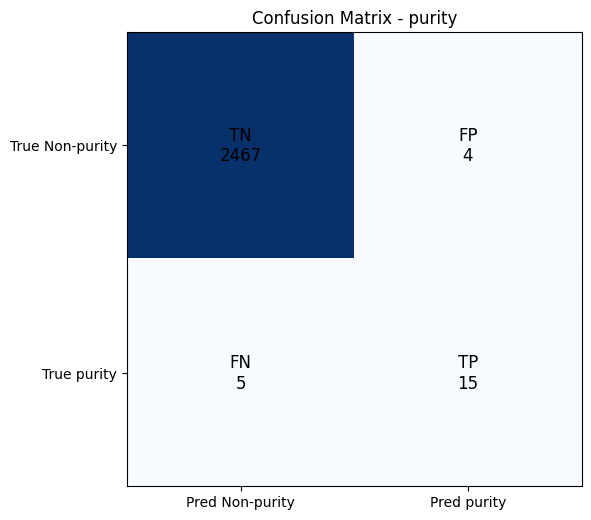

best_F1 0.7692307692307693
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'purity' to: /content/drive/MyDrive/moralbert_inggris/purity
Epoch: 3


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.7169811320754716

Classification Report:
              precision    recall  f1-score   support

  Non-purity       1.00      0.99      1.00      2471
      purity       0.58      0.95      0.72        20

    accuracy                           0.99      2491
   macro avg       0.79      0.97      0.86      2491
weighted avg       1.00      0.99      0.99      2491


Train loss: 0.38030318143279745
Validation loss: 0.3494440254110556


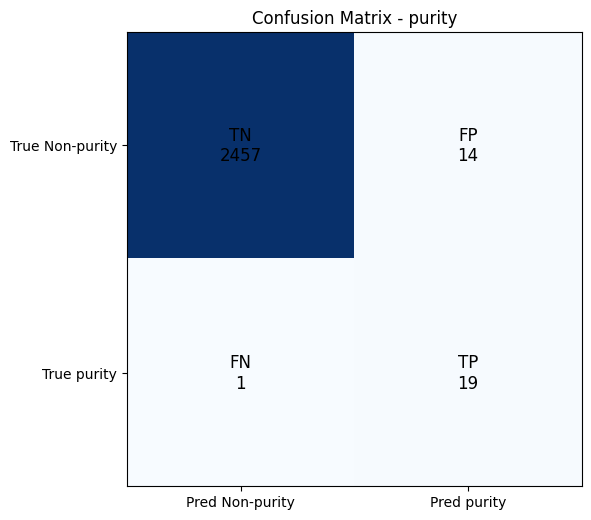

Epoch: 4


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.926829268292683

Classification Report:
              precision    recall  f1-score   support

  Non-purity       1.00      1.00      1.00      2471
      purity       0.90      0.95      0.93        20

    accuracy                           1.00      2491
   macro avg       0.95      0.97      0.96      2491
weighted avg       1.00      1.00      1.00      2491


Train loss: 0.3354318789647441
Validation loss: 0.35405964098679715


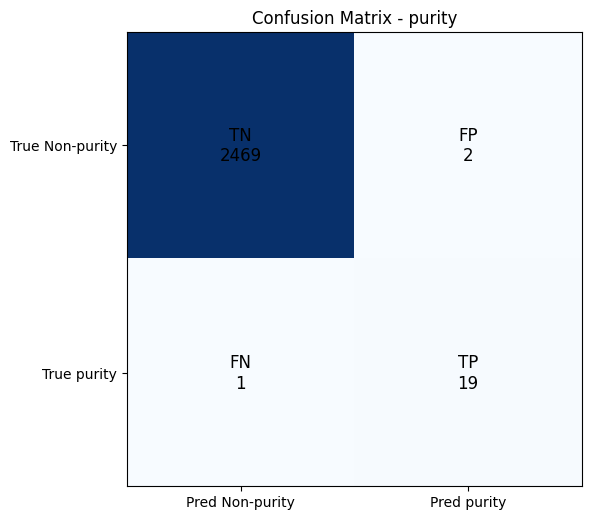

best_F1 0.926829268292683
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'purity' to: /content/drive/MyDrive/moralbert_inggris/purity
Epoch: 5


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.926829268292683

Classification Report:
              precision    recall  f1-score   support

  Non-purity       1.00      1.00      1.00      2471
      purity       0.90      0.95      0.93        20

    accuracy                           1.00      2491
   macro avg       0.95      0.97      0.96      2491
weighted avg       1.00      1.00      1.00      2491


Train loss: 0.3274705779303708
Validation loss: 0.35501337357056445


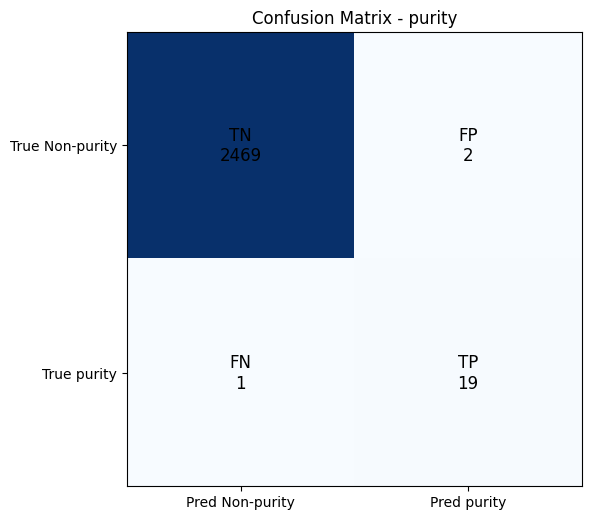

Models for predicting moral dimension with BERT Base
Label: degradation
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for degradation:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.0

Classification Report:
                 precision    recall  f1-score   support

Non-degradation       1.00      1.00      1.00      2483
    degradation       0.00      0.00      0.00         8

       accuracy                           1.00      2491
      macro avg       0.50      0.50      0.50      2491
   weighted avg       0.99      1.00      1.00      2491


Train loss: 0.554832032748631
Validation loss: 0.4928616986442835


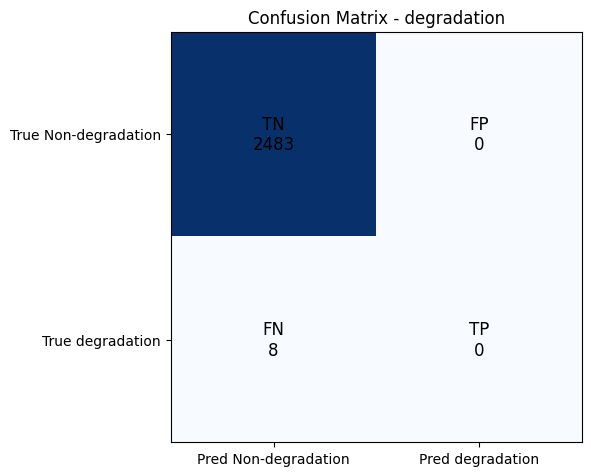

best_F1 0.0
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'degradation' to: /content/drive/MyDrive/moralbert_inggris/degradation
Epoch: 2


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8

Classification Report:
                 precision    recall  f1-score   support

Non-degradation       1.00      1.00      1.00      2483
    degradation       0.86      0.75      0.80         8

       accuracy                           1.00      2491
      macro avg       0.93      0.87      0.90      2491
   weighted avg       1.00      1.00      1.00      2491


Train loss: 0.3935406824654599
Validation loss: 0.37546750597464734


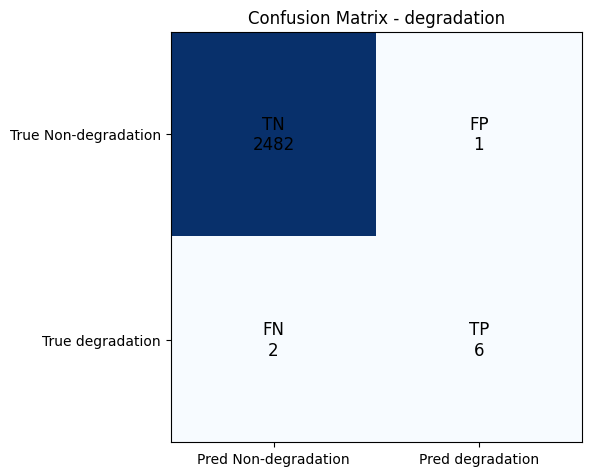

best_F1 0.8
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'degradation' to: /content/drive/MyDrive/moralbert_inggris/degradation
Epoch: 3


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8

Classification Report:
                 precision    recall  f1-score   support

Non-degradation       1.00      1.00      1.00      2483
    degradation       0.86      0.75      0.80         8

       accuracy                           1.00      2491
      macro avg       0.93      0.87      0.90      2491
   weighted avg       1.00      1.00      1.00      2491


Train loss: 0.34342950233295677
Validation loss: 0.3736400929016945


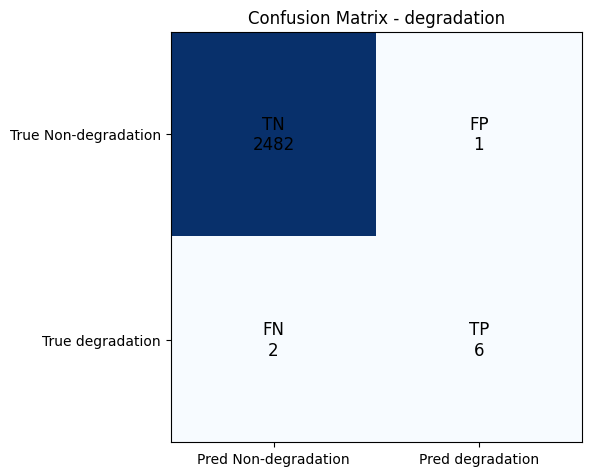

Epoch: 4


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.75

Classification Report:
                 precision    recall  f1-score   support

Non-degradation       1.00      1.00      1.00      2483
    degradation       0.75      0.75      0.75         8

       accuracy                           1.00      2491
      macro avg       0.87      0.87      0.87      2491
   weighted avg       1.00      1.00      1.00      2491


Train loss: 0.33952738528841
Validation loss: 0.36820225685070723


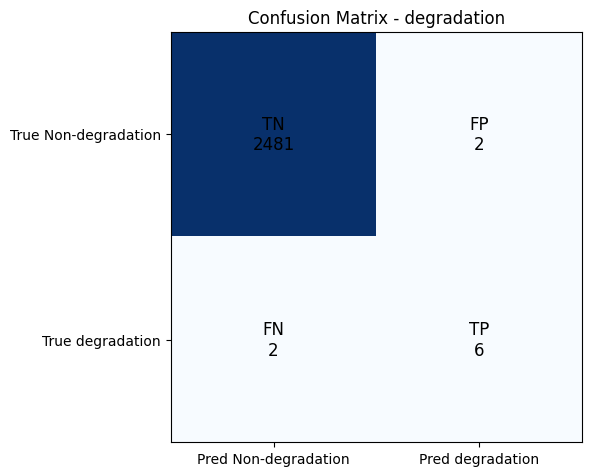

Epoch: 5


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.75

Classification Report:
                 precision    recall  f1-score   support

Non-degradation       1.00      1.00      1.00      2483
    degradation       0.75      0.75      0.75         8

       accuracy                           1.00      2491
      macro avg       0.87      0.87      0.87      2491
   weighted avg       1.00      1.00      1.00      2491


Train loss: 0.32573380501848165
Validation loss: 0.37113206948225314


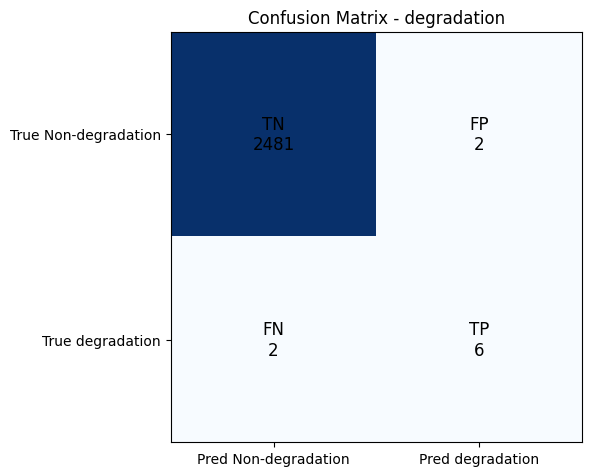

Models for predicting moral dimension with BERT Base
Label: liberty
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for liberty:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.5161290322580645

Classification Report:
              precision    recall  f1-score   support

 Non-liberty       0.99      1.00      1.00      2468
     liberty       1.00      0.35      0.52        23

    accuracy                           0.99      2491
   macro avg       1.00      0.67      0.76      2491
weighted avg       0.99      0.99      0.99      2491


Train loss: 0.6751060583426902
Validation loss: 0.4978116301771922


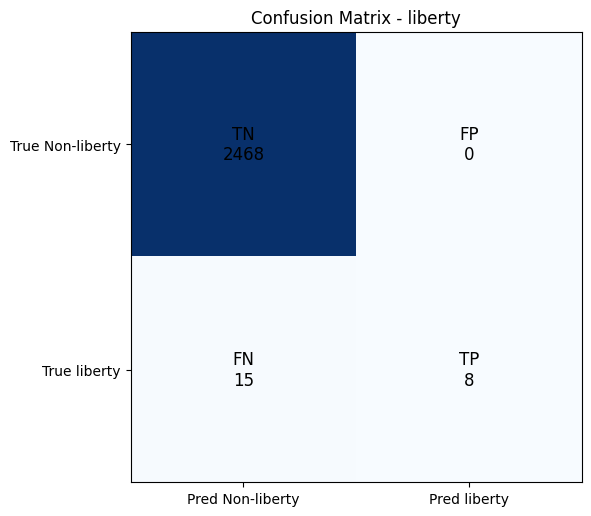

best_F1 0.5161290322580645
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'liberty' to: /content/drive/MyDrive/moralbert_inggris/liberty
Epoch: 2


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9166666666666666

Classification Report:
              precision    recall  f1-score   support

 Non-liberty       1.00      1.00      1.00      2468
     liberty       0.88      0.96      0.92        23

    accuracy                           1.00      2491
   macro avg       0.94      0.98      0.96      2491
weighted avg       1.00      1.00      1.00      2491


Train loss: 0.4161755799960172
Validation loss: 0.3426814277966817


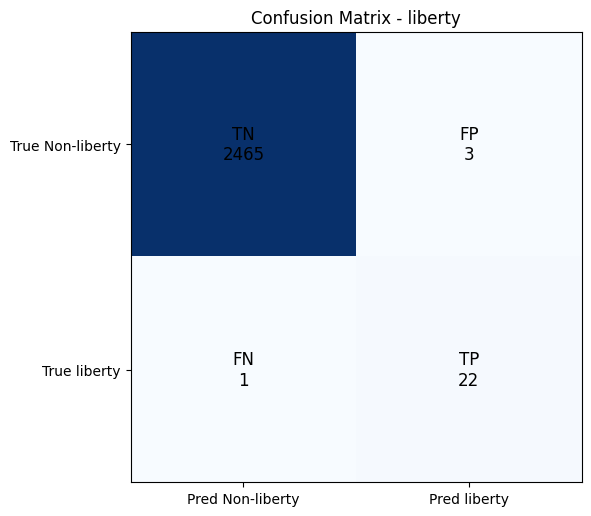

best_F1 0.9166666666666666
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'liberty' to: /content/drive/MyDrive/moralbert_inggris/liberty
Epoch: 3


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9166666666666666

Classification Report:
              precision    recall  f1-score   support

 Non-liberty       1.00      1.00      1.00      2468
     liberty       0.88      0.96      0.92        23

    accuracy                           1.00      2491
   macro avg       0.94      0.98      0.96      2491
weighted avg       1.00      1.00      1.00      2491


Train loss: 0.33919331125233376
Validation loss: 0.33483059188494313


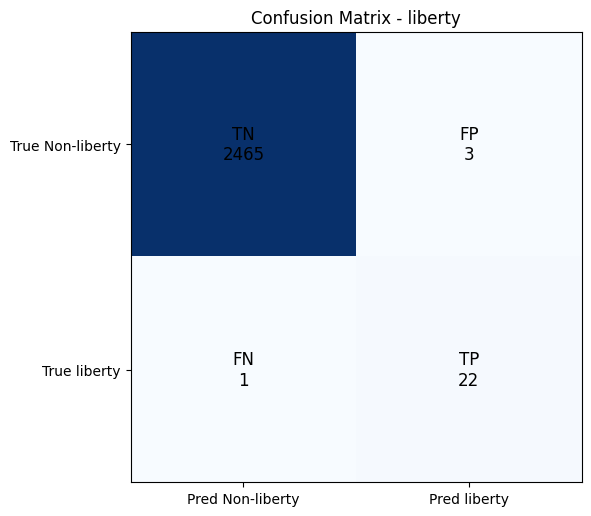

Epoch: 4


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9361702127659575

Classification Report:
              precision    recall  f1-score   support

 Non-liberty       1.00      1.00      1.00      2468
     liberty       0.92      0.96      0.94        23

    accuracy                           1.00      2491
   macro avg       0.96      0.98      0.97      2491
weighted avg       1.00      1.00      1.00      2491


Train loss: 0.3264745945532479
Validation loss: 0.33451391259829205


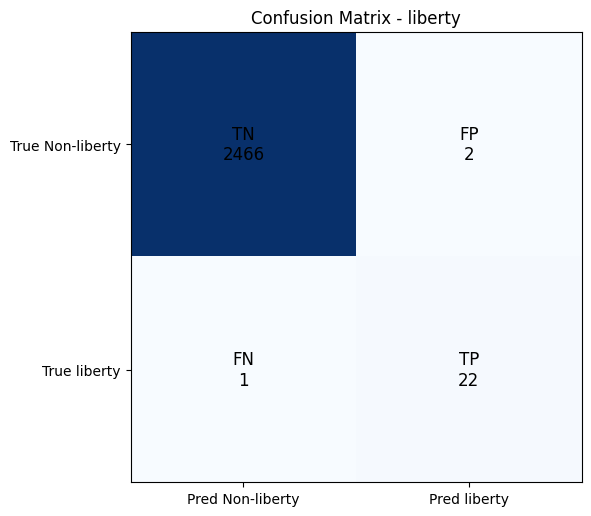

best_F1 0.9361702127659575
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'liberty' to: /content/drive/MyDrive/moralbert_inggris/liberty
Epoch: 5


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9361702127659575

Classification Report:
              precision    recall  f1-score   support

 Non-liberty       1.00      1.00      1.00      2468
     liberty       0.92      0.96      0.94        23

    accuracy                           1.00      2491
   macro avg       0.96      0.98      0.97      2491
weighted avg       1.00      1.00      1.00      2491


Train loss: 0.3242659953394441
Validation loss: 0.3345617930858563


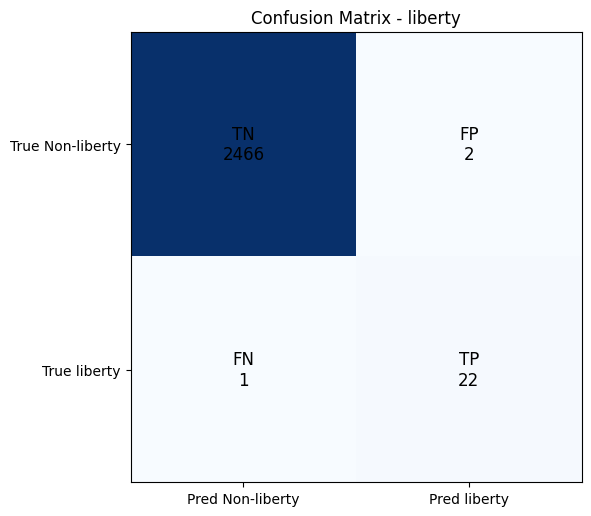

Models for predicting moral dimension with BERT Base
Label: oppression
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for oppression:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.5555555555555556

Classification Report:
                precision    recall  f1-score   support

Non-oppression       1.00      1.00      1.00      2475
    oppression       0.50      0.62      0.56        16

      accuracy                           0.99      2491
     macro avg       0.75      0.81      0.78      2491
  weighted avg       0.99      0.99      0.99      2491


Train loss: 0.6087559144914054
Validation loss: 0.44220023296582395


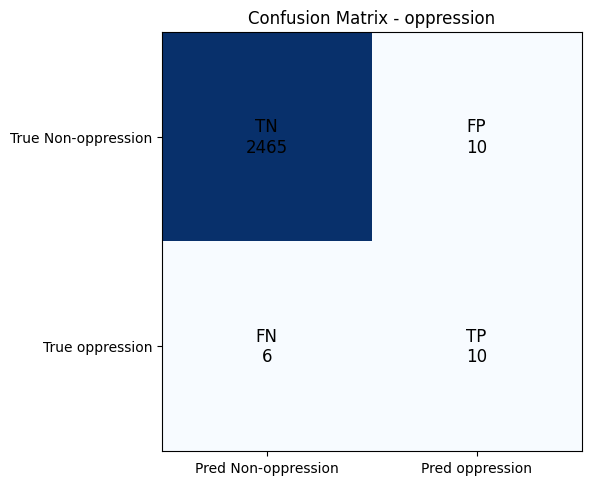

best_F1 0.5555555555555556
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'oppression' to: /content/drive/MyDrive/moralbert_inggris/oppression
Epoch: 2


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8333333333333334

Classification Report:
                precision    recall  f1-score   support

Non-oppression       1.00      1.00      1.00      2475
    oppression       0.75      0.94      0.83        16

      accuracy                           1.00      2491
     macro avg       0.87      0.97      0.92      2491
  weighted avg       1.00      1.00      1.00      2491


Train loss: 0.41568821166338543
Validation loss: 0.3417001865231074


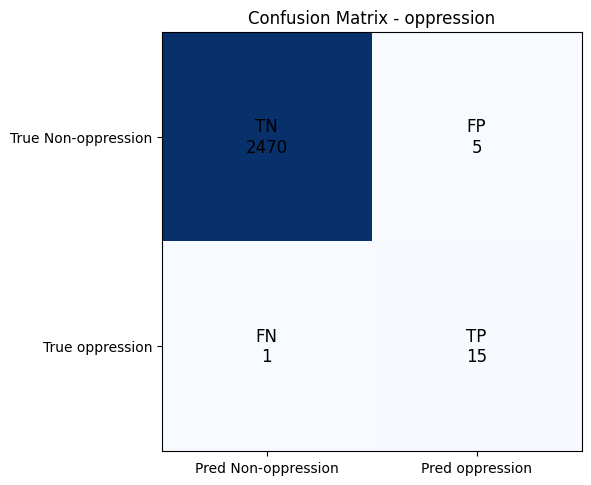

best_F1 0.8333333333333334
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'oppression' to: /content/drive/MyDrive/moralbert_inggris/oppression
Epoch: 3


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8666666666666667

Classification Report:
                precision    recall  f1-score   support

Non-oppression       1.00      1.00      1.00      2475
    oppression       0.93      0.81      0.87        16

      accuracy                           1.00      2491
     macro avg       0.96      0.91      0.93      2491
  weighted avg       1.00      1.00      1.00      2491


Train loss: 0.3455094816596703
Validation loss: 0.34029253247456676


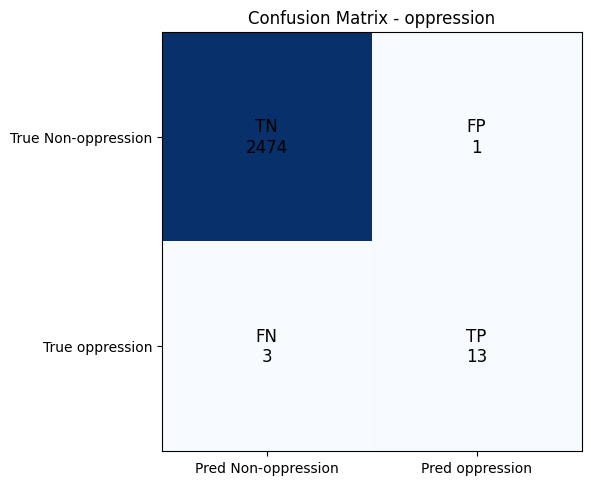

best_F1 0.8666666666666667
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'oppression' to: /content/drive/MyDrive/moralbert_inggris/oppression
Epoch: 4


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8823529411764706

Classification Report:
                precision    recall  f1-score   support

Non-oppression       1.00      1.00      1.00      2475
    oppression       0.83      0.94      0.88        16

      accuracy                           1.00      2491
     macro avg       0.92      0.97      0.94      2491
  weighted avg       1.00      1.00      1.00      2491


Train loss: 0.3272965011302005
Validation loss: 0.33669999967782926


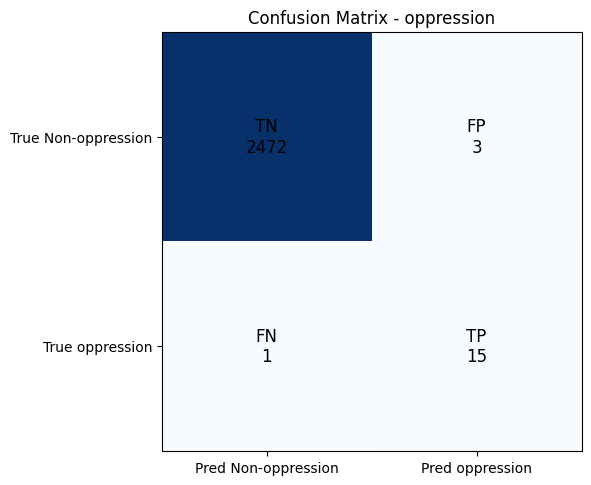

best_F1 0.8823529411764706
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'oppression' to: /content/drive/MyDrive/moralbert_inggris/oppression
Epoch: 5


/tmp/ipykernel_13171/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_13171/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.875

Classification Report:
                precision    recall  f1-score   support

Non-oppression       1.00      1.00      1.00      2475
    oppression       0.88      0.88      0.88        16

      accuracy                           1.00      2491
     macro avg       0.94      0.94      0.94      2491
  weighted avg       1.00      1.00      1.00      2491


Train loss: 0.3242734241543
Validation loss: 0.3385980404340304


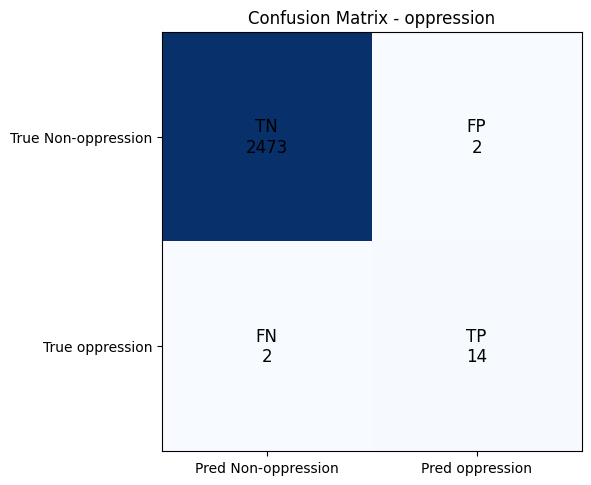

,label,best_f1,best_epoch,export_dir
0,care,0.964286,3,/content/drive/MyDrive/moralbert_inggris/care
1,harm,0.927928,4,/content/drive/MyDrive/moralbert_inggris/harm
2,fairness,0.940299,4,/content/drive/MyDrive/moralbert_inggris/fairness
3,cheating,0.850000,5,/content/drive/MyDrive/moralbert_inggris/cheating
4,loyalty,0.763636,4,/content/drive/MyDrive/moralbert_inggris/loyalty
5,betrayal,0.823529,4,/content/drive/MyDrive/moralbert_inggris/betrayal
6,authority,0.982301,4,/content/drive/MyDrive/moralbert_inggris/autho...
7,subversion,0.727273,3,/content/drive/MyDrive/moralbert_inggris/subve...
8,purity,0.926829,4,/content/drive/MyDrive/moralbert_inggris/purity
9,degradation,0.800000,2,/content/drive/MyDrive/moralbert_inggris/degra...


In [17]:
from torch.cuda.amp import GradScaler, autocast

scaler = GradScaler()

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

possible_labels = [
    "care", "harm",
    "fairness", "cheating",
    "loyalty", "betrayal",
    "authority", "subversion",
    "purity", "degradation",
    "liberty", "oppression"
]

bert_original_embeddings = None
training_summary = []

for lab_idx, lab in enumerate(possible_labels):

    best_f1 = -1
    best_epoch = -1

    num_labels = 2
    epochs = 5
    batch_size = 16

    rw = 0.1
    iw = 0.01

    print("Models for predicting moral dimension with BERT Base")
    print(f"Label: {lab}")
    print(f"Parameters: reconstruction_weight = {rw}; identity_weight = {iw}")

    temp_bert_model = AutoModel.from_pretrained(base_model).to(
        torch.device("cuda" if torch.cuda.is_available() else "cpu")
    )

    if bert_original_embeddings is None:
        bert_original_embeddings = encode_corpus(
            train_input_ids,
            train_attention_masks,
            temp_bert_model
        )

    train_binary_labels = train_df[lab].astype(int).tolist()
    val_binary_labels = test_df[lab].astype(int).tolist()

    positive_ratio = sum(train_binary_labels) / len(train_binary_labels)
    class_weight = [positive_ratio, 1 - positive_ratio]

    train_set = TensorDataset(
        train_input_ids,
        train_token_type_ids,
        train_attention_masks,
        torch.tensor(train_binary_labels, dtype=torch.long),
        bert_original_embeddings
    )

    val_set = TensorDataset(
        test_input_ids,
        test_token_type_ids,
        test_attention_masks,
        torch.tensor(val_binary_labels, dtype=torch.long)
    )

    train_dataloader = DataLoader(train_set, sampler=RandomSampler(train_set), batch_size=batch_size)
    validation_dataloader = DataLoader(val_set, batch_size=batch_size)

    total_steps = len(train_dataloader) * epochs
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    config = PlainBERTConfig(
        base_model_name_or_path=base_model,
        num_labels=num_labels,
        class_weight=[float(class_weight[0]), float(class_weight[1])],
        reconstruction_weight=rw,
        identity_weight=iw,
        moral_weight=1.0,
        freeze_bert=False,
        id2label={"0": f"Non-{lab}", "1": lab},
        label2id={f"Non-{lab}": 0, lab: 1},
    )

    model = PlainBERTForSequenceClassification(config).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=total_steps
    )

    for epoch in trange(epochs, desc=f"Epochs for {lab}"):

        print("Epoch:", epoch + 1)
        model.train()

        tr_loss = 0
        nb_tr_steps = 0

        for step, batch in enumerate(train_dataloader):
            batch = tuple(t.to(device) for t in batch)
            b_input_ids, b_token_type_ids, b_input_mask, b_labels, bert_embeddings = batch

            optimizer.zero_grad()

            with autocast():
                outputs = model(
                    input_ids=b_input_ids,
                    token_type_ids=b_token_type_ids,
                    attention_mask=b_input_mask,
                    labels=b_labels,
                    original_bert_embeddings=bert_embeddings
                )
                loss = outputs.loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            tr_loss += loss.item()
            nb_tr_steps += 1

        model.eval()
        val_loss = 0
        nb_val_steps = 0
        y_true = []
        y_pred = []

        for batch in validation_dataloader:
            batch = tuple(t.to(device) for t in batch)
            b_input_ids, b_token_type_ids, b_input_mask, b_labels = batch

            with torch.no_grad():
                with autocast():
                    outputs = model(
                        input_ids=b_input_ids,
                        token_type_ids=b_token_type_ids,
                        attention_mask=b_input_mask,
                        labels=b_labels
                    )

                val_loss += outputs.loss.item()
                logits = outputs.logits.detach().cpu().numpy()
                label_ids = b_labels.detach().cpu().numpy()
                predicted_labels = np.argmax(logits, axis=1)

                y_true.extend(label_ids)
                y_pred.extend(predicted_labels)
                nb_val_steps += 1

        print("Evaluation")
        target_names = [f"Non-{lab}", lab]
        report = classification_report(y_true, y_pred, target_names=target_names, zero_division=0)
        f1 = f1_score(y_true, y_pred, average="binary", zero_division=0)

        print(f"F1 score: {f1}")
        print("\nClassification Report:")
        print(report)
        print(f"\nTrain loss: {tr_loss / max(nb_tr_steps, 1)}")
        print(f"Validation loss: {val_loss / max(nb_val_steps, 1)}")

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        fig, ax = plt.subplots(figsize=(6, 6))

        matrix_display = [
            [tn, fp],
            [fn, tp]
        ]

        im = ax.imshow(matrix_display, cmap="Blues")

        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels([f"Pred Non-{lab}", f"Pred {lab}"])
        ax.set_yticklabels([f"True Non-{lab}", f"True {lab}"])

        ax.set_title(f"Confusion Matrix - {lab}")

        labels_text = [
            [f"TN\n{tn}", f"FP\n{fp}"],
            [f"FN\n{fn}", f"TP\n{tp}"]
        ]

        for i in range(2):
            for j in range(2):
                ax.text(j, i, labels_text[i][j], ha="center", va="center", fontsize=12)

        plt.tight_layout()
        plt.show()

        if f1 > best_f1:
            best_f1 = f1
            best_epoch = epoch + 1
            print("best_F1", best_f1)
            print("Saving best native Hugging Face model ...")

            export_native_plainbert_checkpoint(
                model=model,
                tokenizer=tokenizer,
                export_root=HF_EXPORT_ROOT,
                label_name=lab,
                best_f1=best_f1,
                threshold=0.5
            )

    del temp_bert_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    training_summary.append({
        "label": lab,
        "best_f1": best_f1,
        "best_epoch": best_epoch,
        "export_dir": str(HF_EXPORT_ROOT / lab.replace(" ", "_"))
    })

training_summary = pd.DataFrame(training_summary)
training_summary

# Predictions

In [18]:
test_df = pd.read_csv("test_inggris.csv")

In [19]:
test_df.shape

(2491, 16)

In [20]:
# pd.merge(test_df, lib_opp, how = 'inner', on = 'text')

In [21]:
try:
    from google.colab import drive
    DRIVE_ROOT = "/content/drive"
    if not os.path.ismount(DRIVE_ROOT):
        drive.mount(DRIVE_ROOT)
except Exception:
    DRIVE_ROOT = None
HF_EXPORT_ROOT = Path("/content/drive/MyDrive/moralbert_inggris") if DRIVE_ROOT else Path("./moralbert_inggris")

In [22]:
base_model = "bert-base-uncased"
input_files = test_df["sentence"].values

tokenizer = AutoTokenizer.from_pretrained(base_model)

original_input_id = []
original_attention_masks = []
original_token_type_id = []

def preprocessing(input_text, tokenizer):
    return tokenizer(
        input_text,
        add_special_tokens=True,
        max_length=150,
        padding="max_length",
        truncation=True,
        return_attention_mask=True,
        return_token_type_ids=True,
        return_tensors="pt"
    )

for sample in input_files:
    original_encoding_dict = preprocessing(sample, tokenizer)

    original_input_id.append(original_encoding_dict["input_ids"])
    original_attention_masks.append(original_encoding_dict["attention_mask"])

    original_token_type = torch.zeros_like(original_encoding_dict["input_ids"])
    original_token_type[original_encoding_dict["input_ids"] != 0] = 0
    original_token_type_id.append(original_token_type)

original_input_id = torch.cat(original_input_id, dim=0)
original_attention_masks = torch.cat(original_attention_masks, dim=0)
original_token_type_id = torch.cat(original_token_type_id, dim=0)

In [23]:
suffix

'_moral_multilabel_balinese'

In [24]:
import torch

torch.set_default_device("cpu")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [25]:
possible_labels = [
    "care", "harm",
    "fairness", "cheating",
    "loyalty", "betrayal",
    "authority", "subversion",
    "purity", "degradation",
    "liberty", "oppression"
]

import torch
torch.set_default_device("cpu")  # cegah meta device context tetap aktif

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

predictions = []
threshold_summary = []

for lab_idx, lab in enumerate(possible_labels):
    print(f"\nProcessing label: {lab}")

    best_f1 = 0
    best_th = 0.5
    best_y = None
    batch_size = 16

    true_labels_for_lab = test_df[lab].astype(int).tolist()

    val_set = TensorDataset(
        original_input_id,
        original_token_type_id,
        original_attention_masks,
        torch.tensor(true_labels_for_lab, dtype=torch.long)
    )

    validation_dataloader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

    checkpoint_folder = HF_EXPORT_ROOT / lab.replace(" ", "_")

    model = PlainBERTForSequenceClassification.from_pretrained(str(checkpoint_folder))
    model = model.to(device)
    model.eval()

    all_probs = []
    y_true = []

    for batch in validation_dataloader:
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_token_type_ids, b_input_mask, b_labels = batch

        with torch.no_grad():
            outputs = model(
                input_ids=b_input_ids,
                token_type_ids=b_token_type_ids,
                attention_mask=b_input_mask
            )

            logits = outputs.logits.detach().cpu()
            probs = torch.softmax(logits, dim=1).numpy()[:, 1]

            all_probs.extend(probs.tolist())
            y_true.extend(b_labels.detach().cpu().numpy().tolist())

    all_probs = np.array(all_probs)
    y_true = np.array(y_true)

    for th in np.arange(0.05, 1.00, 0.05):
        y_pred = (all_probs >= th).astype(int)
        f1 = f1_score(y_true, y_pred, average="binary", zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_th = th
            best_y = y_pred.copy()

    threshold_summary.append({
        "label": lab,
        "best_threshold": float(best_th),
        "best_f1": float(best_f1)
    })

    if lab_idx == 0:
        for ex_id, (pred_label, true_label) in enumerate(zip(best_y, y_true)):
            predictions.append({
                "id": ex_id,
                f"pred_{lab}": int(pred_label),
                f"true_{lab}": int(true_label)
            })
    else:
        for ex_id, (pred_label, true_label) in enumerate(zip(best_y, y_true)):
            predictions[ex_id][f"pred_{lab}"] = int(pred_label)
            predictions[ex_id][f"true_{lab}"] = int(true_label)

    print("Evaluation")
    print(f"{lab} | best threshold: {best_th:.2f} | best F1: {best_f1:.4f}")

    target_names = [f"Non-{lab}", lab]
    report = classification_report(
        y_true,
        best_y,
        target_names=target_names,
        zero_division=0
    )

    print("\nClassification Report:")
    print(report)

pred_df = pd.DataFrame(predictions)
threshold_df = pd.DataFrame(threshold_summary)


Processing label: care


RuntimeError: You are using `from_pretrained` with a meta device context manager or `torch.set_default_device('meta')`.
This is an anti-pattern as `from_pretrained` wants to load existing weights.
If you want to initialize an empty model on the meta device, use the context manager or global device with `from_config`, or `ModelClass(config)`

In [ ]:
pd.set_option('display.max_columns', None)


In [ ]:
results = []

for idx_lab, lab in enumerate(possible_labels):
    result = {"Moral Value": lab}
    true = test_df[lab].values
    candidate = pred_df["pred_" + lab].values

    result["F1 Score (Binary)"] = f1_score(true, candidate, average="binary", zero_division=0)
    result["F1 Score (Weighted)"] = f1_score(true, candidate, average="weighted", zero_division=0)

    result["Precision Score (Binary)"] = precision_score(true, candidate, average="binary", zero_division=0)
    result["Precision Score (Weighted)"] = precision_score(true, candidate, average="weighted", zero_division=0)

    result["Recall Score (Binary)"] = recall_score(true, candidate, average="binary", zero_division=0)
    result["Recall Score (Weighted)"] = recall_score(true, candidate, average="weighted", zero_division=0)

    result["Accuracy"] = accuracy_score(true, candidate)

    results.append(result)

results = pd.DataFrame(results)

In [ ]:
results

### Bootstraping:

In [ ]:
possible_labels = [
    "kepedulian", "menyakiti",
    "keadilan", "kecurangan",
    "loyalitas", "pengkhianatan",
    "otoritas", "pembangkangan",
    "kesucian", "kemerosotan",
    "kebebasan", "penindasan"
]

test_df.reset_index(drop=True, inplace=True)
n_bootstrap_iters = 1000

bootstrap_results = {
    label: {
        metric: [] for metric in [
            "F1 (Binary)", "F1 (Macro)", "F1 (Weighted)",
            "Precision (Binary)", "Precision (Macro)", "Precision (Weighted)",
            "Recall (Binary)", "Recall (Macro)", "Recall (Weighted)",
            "Accuracy"
        ]
    } for label in possible_labels
}

for _ in range(n_bootstrap_iters):
    for lab in possible_labels:
        sample_indices = resample(np.arange(len(test_df)), replace=True)
        true = test_df.loc[sample_indices, lab].values
        candidate = pred_df.loc[sample_indices, f"pred_{lab}"].values

        bootstrap_results[lab]["F1 (Binary)"].append(f1_score(true, candidate, average="binary", zero_division=0))
        bootstrap_results[lab]["F1 (Macro)"].append(f1_score(true, candidate, average="macro", zero_division=0))
        bootstrap_results[lab]["F1 (Weighted)"].append(f1_score(true, candidate, average="weighted", zero_division=0))
        bootstrap_results[lab]["Precision (Binary)"].append(precision_score(true, candidate, average="binary", zero_division=0))
        bootstrap_results[lab]["Precision (Macro)"].append(precision_score(true, candidate, average="macro", zero_division=0))
        bootstrap_results[lab]["Precision (Weighted)"].append(precision_score(true, candidate, average="weighted", zero_division=0))
        bootstrap_results[lab]["Recall (Binary)"].append(recall_score(true, candidate, average="binary", zero_division=0))
        bootstrap_results[lab]["Recall (Macro)"].append(recall_score(true, candidate, average="macro", zero_division=0))
        bootstrap_results[lab]["Recall (Weighted)"].append(recall_score(true, candidate, average="weighted", zero_division=0))
        bootstrap_results[lab]["Accuracy"].append(accuracy_score(true, candidate))

std_devs = {
    label: {metric: np.std(values) for metric, values in metrics.items()}
    for label, metrics in bootstrap_results.items()
}

final_results = []
for lab in possible_labels:
    result = {"Moral Value": lab}
    true = test_df[lab].values
    candidate = pred_df[f"pred_{lab}"].values

    result["F1 Score (Binary)"] = f"{f1_score(true, candidate, average='binary', zero_division=0):.2f} ± {std_devs[lab]['F1 (Binary)']:.2f}"
    result["F1 Score (Macro)"] = f"{f1_score(true, candidate, average='macro', zero_division=0):.2f} ± {std_devs[lab]['F1 (Macro)']:.2f}"
    result["F1 Score (Weighted)"] = f"{f1_score(true, candidate, average='weighted', zero_division=0):.2f} ± {std_devs[lab]['F1 (Weighted)']:.2f}"

    result["Precision Score (Binary)"] = f"{precision_score(true, candidate, average='binary', zero_division=0):.2f} ± {std_devs[lab]['Precision (Binary)']:.2f}"
    result["Precision Score (Macro)"] = f"{precision_score(true, candidate, average='macro', zero_division=0):.2f} ± {std_devs[lab]['Precision (Macro)']:.2f}"
    result["Precision Score (Weighted)"] = f"{precision_score(true, candidate, average='weighted', zero_division=0):.2f} ± {std_devs[lab]['Precision (Weighted)']:.2f}"

    result["Recall Score (Binary)"] = f"{recall_score(true, candidate, average='binary', zero_division=0):.2f} ± {std_devs[lab]['Recall (Binary)']:.2f}"
    result["Recall Score (Macro)"] = f"{recall_score(true, candidate, average='macro', zero_division=0):.2f} ± {std_devs[lab]['Recall (Macro)']:.2f}"
    result["Recall Score (Weighted)"] = f"{recall_score(true, candidate, average='weighted', zero_division=0):.2f} ± {std_devs[lab]['Recall (Weighted)']:.2f}"

    result["Accuracy"] = f"{accuracy_score(true, candidate):.2f} ± {std_devs[lab]['Accuracy']:.2f}"

    final_results.append(result)

results_df = pd.DataFrame(final_results)
results_df

In [ ]:
results_df